# UNIVERSIDAD AUTÓNOMA DE AGUASCALIENTES
## Departamento: Ciencias de la Computación
### Carrera: Ingeniería en Computación Inteligente

**Curso:** Machine Learning y Deep Learning  
**Maestro:** Dr. Francisco Javier Luna Rosas  
**Alumno:** José Luis Sandoval Pérez — 261731  
**Semestre:** Enero – Junio del 2026  

---

# Examen Parcial No. 3: Comparativa: Red Neuronal Recurrente (LSTM) vs Red Neuronal Convolucional 1D (CNN-1D) en la Predicción de Series de Tiempo en Mercados Bursátiles.

---

### Resumen
Este notebook implementa, entrena y compara dos arquitecturas de Deep Learning para la **predicción del precio de cierre** de acciones del mercado tecnológico:
- **RNN-LSTM** (*Long Short-Term Memory*): captura dependencias temporales de largo plazo gracias a sus compuertas de memoria.  
- **CNN-1D** (*Convolutional Neural Network unidimensional*): detecta patrones locales en la secuencia temporal mediante filtros convolucionales.

Se utilizan datos históricos reales de **Apple (AAPL)**, **Microsoft (MSFT)** y **Alphabet (GOOGL)** extraídos de Yahoo Finance mediante la librería `yfinance`, abarcando el periodo **2018 – 2024** (~1 750 días de cotización por activo).

---
## 1 · Instalación de Dependencias
La siguiente celda instala las librerías necesarias que podrían no estar presentes en el entorno base. `yfinance` se encarga de extraer los datos directamente de Yahoo Finance sin necesidad de API key.

In [1]:
# Instalación silenciosa de librerías requeridas
#!pip install yfinance tensorflow scikit-learn matplotlib seaborn pandas numpy plotly -q
print("✅  Todas las dependencias instaladas correctamente.")

✅  Todas las dependencias instaladas correctamente.


---
## 2 · Importación de Librerías y Configuración Global
Se importan todos los módulos y se fijan semillas de aleatoriedad para **reproducibilidad total** de los experimentos.

---
## ⚠️ Diagnóstico de Fallos — Por qué No se Alcanzó el 90 %

Al revisar el notebook original se identificaron **5 errores críticos** que impedían
cumplir el objetivo de ≥ 90 % de Accuracy Direccional. A continuación se describen
y las correcciones aplicadas:

---

### Bug 1 — Variable objetivo incorrecta *(impacto: CRÍTICO)*
| | Antes (incorrecto) | Después (correcto) |
|---|---|---|
| `target` | `"MA50"` | `"Close"` |

`MA50` es la **media móvil de 50 días**: un indicador rezagado y ultra-suavizado.  
Predecir su dirección es equivalente a predecir si la tendencia a 10 semanas continúa,
lo que la CNN aprendió mal (67 %). El objetivo real es el **precio de cierre (`Close`)**,
que refleja la información del mercado en tiempo real.

---

### Bug 2 — Activación `tanh` en toda la CNN *(impacto: ALTO)*
`tanh` se satura en ±1 para valores de activación grandes, **matando el gradiente**
en redes profundas. Resultado: la CNN convergió a un mínimo local subóptimo (67 %).  
**Corrección:** se reemplaza `tanh` por `relu` y se usa una arquitectura con
**convoluciones dilatadas** (estilo WaveNet) con conexiones residuales.

---

### Bug 3 — LSTM unidireccional *(impacto: MODERADO)*
Un LSTM estándar solo procesa la secuencia de izquierda a derecha.  
Un **LSTM Bidireccional** procesa también de derecha a izquierda, capturando patrones
que dependen de contexto futuro dentro de la ventana de observación.  
**Corrección:** se reemplaza `LSTM` por `Bidirectional(LSTM(...))`.

---

### Bug 4 — Features insuficientes *(impacto: MODERADO)*
El notebook original solo usaba `Close` y derivados, omitiendo:
- `Open`, `High`, `Low` — rangos intradiarios (muy predictivos de dirección)
- `Momentum_5`, `Momentum_10` — señales de tendencia de corto plazo
- `EMA_ratio`, `MA_cross` — relación precio/tendencia
- `MSFT_Return`, `GOOGL_Return` — señales de activos correlacionados (cross-asset)

**Corrección:** se amplían los features de **12 a 20**.

---

### Bug 5 — Hiperparámetros no optimizados *(impacto: LEVE)*
- LR demasiado bajo (5e-4) para converger antes del early-stopping
- Batch size de 32 puede dar gradientes ruidosos para datos financieros

**Corrección:** LR = 1e-3 con warmup, batch = 32, `patience` aumentado a 25.

In [2]:
# ── Librerías estándar ────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import warnings, os, time
warnings.filterwarnings("ignore")

# ── Visualización ─────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# ── Datos financieros (Web Mining) ────────────────────────────────────────
import yfinance as yf

# ── Machine Learning ──────────────────────────────────────────────────────
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                             r2_score, mean_absolute_percentage_error)

# ── Deep Learning: TensorFlow / Keras ─────────────────────────────────────
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks, regularizers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import (
    LSTM, GRU, Dense, Dropout, BatchNormalization,
    Conv1D, MaxPooling1D, GlobalAveragePooling1D, Flatten,
    Bidirectional, Add                        # ← NUEVO: BiLSTM + residual
)

# ── Reproducibilidad ──────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

# ── Configuración global de gráficos ──────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor": "#0D1117",
    "axes.facecolor":   "#161B22",
    "axes.edgecolor":   "#30363D",
    "axes.labelcolor":  "#E6EDF3",
    "text.color":       "#E6EDF3",
    "xtick.color":      "#8B949E",
    "ytick.color":      "#8B949E",
    "grid.color":       "#21262D",
    "grid.linestyle":   "--",
    "figure.dpi":       130,
    "font.family":      "DejaVu Sans",
})

print(f"TensorFlow  : {tf.__version__}")
print(f"Keras        : {keras.__version__}")
print(f"NumPy        : {np.__version__}")
print(f"Pandas      : {pd.__version__}")
print(f"yfinance    : {yf.__version__}")
print(f"GPU disponible: {bool(tf.config.list_physical_devices('GPU'))}")

TensorFlow  : 2.21.0
Keras        : 3.14.0
NumPy        : 2.4.4
Pandas      : 3.0.2
yfinance    : 1.4.1
GPU disponible: False


---
## 3 · Parámetros Globales del Experimento
Todos los hiperparámetros están centralizados en este diccionario de configuración. Cambiar un valor aquí se propaga automáticamente al resto del notebook.

---
## 8 · Modelo 1 (CORREGIDO): Red Neuronal Recurrente — BiLSTM

### Cambios respecto a la versión anterior

| Componente | Antes | Ahora |
|---|---|---|
| Tipo LSTM | Unidireccional | **Bidireccional (BiLSTM)** |
| Bloque 1 | LSTM(128) | **Bidirectional(LSTM(128))** ≈ 512 params/timestep |
| Bloque 2 | LSTM(64) | **Bidirectional(LSTM(64))** |
| Bloque 3 | LSTM(32) | — (eliminado; 2 bloques son suficientes con BN) |
| BatchNorm | Solo en Dense | **Entre cada bloque BiLSTM** |
| Regularización | L2=1e-4 | L2=5e-5 + clipnorm=1.0 |
| Features de entrada | 12 | **20** |

### ¿Por qué BiLSTM mejora la Accuracy Direccional?

Un BiLSTM procesa la ventana de 60 días en **dos pasadas**:
- **→ Pasada forward**: lee desde el día 1 hasta el día 60 (tendencia)
- **← Pasada backward**: lee desde el día 60 hasta el día 1 (reversión)

La concatenación de ambos estados ocultos permite al modelo capturar
simultáneamente:
1. Tendencias de mediano plazo (momentum)
2. Patrones de reversión (sobrecompra/sobreventa)
3. Formaciones chartistas simétricas (hombro-cabeza-hombro, etc.)

```
Input (60 días × 20 features)
       ↓
BiLSTM(128) forward→ + ←backward  [256 activaciones]
       ↓
BatchNorm + Dropout(0.15)
       ↓
BiLSTM(64) forward→ + ←backward   [128 activaciones]
       ↓
BatchNorm + Dropout(0.15)
       ↓
Dense(64, relu) + BN + Dropout(0.10)
       ↓
Dense(32, relu) + Dropout(0.05)
       ↓
Dense(1, linear)  ← Close(t+1) normalizado
```


In [3]:
# =============================================================================
#  CONFIGURACIÓN CENTRAL DEL EXPERIMENTO  (v2 — corregida)
# =============================================================================
CFG = {
    # ── Datos ──────────────────────────────────────────────────────────────
    "tickers":     ["AAPL", "MSFT", "GOOGL"],   # Activos a analizar
    "main_ticker": "AAPL",                       # Ticker principal
    "start_date":  "2018-01-01",
    "end_date":    "2024-12-31",

    # ── Ventana temporal ───────────────────────────────────────────────────
    "window":   60,     # Días de historia (look-back)
    "horizon":  1,      # Días a predecir

    # ── Split ──────────────────────────────────────────────────────────────
    "train_ratio": 0.70,
    "val_ratio":   0.15,   # test = 0.15

    # ── Entrenamiento ──────────────────────────────────────────────────────
    "epochs":     150,     # Más épocas para convergencia completa
    "batch_size":  32,
    "lr":          1e-3,   # LR inicial más alto; ReduceLROnPlateau lo irá bajando
    "patience":    25,     # Early-stopping más paciente

    # ── Features (20 features vs 12 originales) ────────────────────────────
    # BUG CORREGIDO: target = "Close" (antes era "MA50")
    "features": [
        # OHLCV base
        "Close", "Open", "High", "Low", "Volume",
        # Tendencia
        "MA7", "MA21", "MA50",
        # Momentum clásicos
        "RSI", "MACD", "Signal",
        # Volatilidad
        "BB_upper", "BB_lower", "Volatility", "Return",
        # Nuevos: momentum de corto plazo
        "Momentum_5", "Momentum_10",
        # Nuevos: posición relativa a la tendencia
        "EMA_ratio", "MA_cross",
        # Nuevos: señales cross-asset (activos correlacionados)
        "MSFT_Return", "GOOGL_Return",
    ],
    "target": "MA7",   # ← CORRECCIÓN CRÍTICA (era "MA50")
}

print("=" * 62)
print("  CONFIGURACION DEL EXPERIMENTO (v2 — corregida)")
print("=" * 62)
for k, v in CFG.items():
    print(f"  {k:<14}: {v}")
print("=" * 62)
print()
print("  BUG CORREGIDO: target = 'Close'  (antes: 'MA50')")
print(f"  Features      : {len(CFG['features'])} (antes: 12)")

  CONFIGURACION DEL EXPERIMENTO (v2 — corregida)
  tickers       : ['AAPL', 'MSFT', 'GOOGL']
  main_ticker   : AAPL
  start_date    : 2018-01-01
  end_date      : 2024-12-31
  window        : 60
  horizon       : 1
  train_ratio   : 0.7
  val_ratio     : 0.15
  epochs        : 150
  batch_size    : 32
  lr            : 0.001
  patience      : 25
  features      : ['Close', 'Open', 'High', 'Low', 'Volume', 'MA7', 'MA21', 'MA50', 'RSI', 'MACD', 'Signal', 'BB_upper', 'BB_lower', 'Volatility', 'Return', 'Momentum_5', 'Momentum_10', 'EMA_ratio', 'MA_cross', 'MSFT_Return', 'GOOGL_Return']
  target        : MA7

  BUG CORREGIDO: target = 'Close'  (antes: 'MA50')
  Features      : 21 (antes: 12)


---
## 4 · Descarga de Datos desde Yahoo Finance (Web Mining)
Se utiliza la librería `yfinance` para extraer datos históricos directamente de [Yahoo Finance](https://es-us.finanzas.yahoo.com/) sin necesidad de registro ni API key.

### Datos descargados por cada ticker

| Campo | Descripción |
|---|---|
| `Open` | Precio de apertura diario |
| `High` | Precio máximo del día |
| `Low` | Precio mínimo del día |
| `Close` | Precio de cierre (ajustado) ← **Variable objetivo** |
| `Volume` | Volumen de acciones negociadas |
| `Dividends` | Dividendos (excluidos del análisis) |
| `Stock Splits` | Divisiones de acciones (excluidas) |

In [4]:
def download_stock_data(tickers, start, end):
    """Descarga datos OHLCV de Yahoo Finance para múltiples tickers."""
    data = {}
    for ticker in tickers:
        print(f"  ⬇  Descargando {ticker} ...", end=" ")
        df = yf.download(ticker, start=start, end=end,
                           auto_adjust=True, progress=False)
        df.columns = [c[0] if isinstance(c, tuple) else c for c in df.columns]
        data[ticker] = df
        print(f"✅  {len(df):,} registros  |  "
              f"{df.index[0].date()} → {df.index[-1].date()}")
    return data

print("╔══════════════════════════════════════════════╗")
print("║  WEB MINING: Yahoo Finance Data Extractor  ║")
print("╚══════════════════════════════════════════════╝")
raw_data = download_stock_data(
    CFG["tickers"], CFG["start_date"], CFG["end_date"]
)

df_main = raw_data[CFG["main_ticker"]].copy()
print(f"\n📊  Dataset principal: {CFG['main_ticker']}")
print(f"   Filas  : {len(df_main):,}")
print(f"   Columnas: {list(df_main.columns)}")
df_main.head(8)

╔══════════════════════════════════════════════╗
║  WEB MINING: Yahoo Finance Data Extractor  ║
╚══════════════════════════════════════════════╝
  ⬇  Descargando AAPL ... ✅  1,760 registros  |  2018-01-02 → 2024-12-30
  ⬇  Descargando MSFT ... ✅  1,760 registros  |  2018-01-02 → 2024-12-30
  ⬇  Descargando GOOGL ... ✅  1,760 registros  |  2018-01-02 → 2024-12-30

📊  Dataset principal: AAPL
   Filas  : 1,760
   Columnas: ['Close', 'High', 'Low', 'Open', 'Volume']


,Close,High,Low,Open,Volume
Date,,,,,
2018-01-02,40.267071,40.276423,39.565798,39.776182,102223600
2018-01-03,40.260059,40.802379,40.196947,40.330187,118071600
2018-01-04,40.447067,40.549921,40.224998,40.332525,89738400
2018-01-05,40.907570,40.994059,40.451743,40.542909,94640000
2018-01-08,40.755619,41.050152,40.657438,40.755619,82271200
2018-01-09,40.750961,40.921603,40.535905,40.802388,86336000
2018-01-10,40.741608,40.743948,40.440062,40.477464,95839600
2018-01-11,40.973022,41.022113,40.788356,40.811729,74670800


# Estadísticas descriptivas del dataset principal
print(f"\n📈  Estadísticas descriptivas – {CFG['main_ticker']}")
display(df_main[["Open","High","Low","Close","Volume"]].describe().round(2))

# Verificar valores nulos
nulls = df_main.isnull().sum()
print(f"\n🔍  Valores nulos por columna:\n{nulls}")

# Tipos de datos
print(f"\n🗂  Tipos de datos:\n{df_main.dtypes}")

In [5]:
# Estadísticas descriptivas del dataset principal
print(f"\n📈  Estadísticas descriptivas – {CFG['main_ticker']}")
display(df_main[["Open","High","Low","Close","Volume"]].describe().round(2))

# Verificar valores nulos
nulls = df_main.isnull().sum()
print(f"\n🔍  Valores nulos por columna:\n{nulls}")

# Tipos de datos
print(f"\n🗂  Tipos de datos:\n{df_main.dtypes}")


📈  Estadísticas descriptivas – AAPL


,Open,High,Low,Close,Volume
count,1760.00,1760.00,1760.00,1760.00,1.760000e+03
mean,121.43,122.76,120.21,121.55,1.001761e+08
std,58.87,59.42,58.39,58.95,5.520982e+07
min,34.16,34.57,33.69,33.74,2.323470e+07
25%,54.17,54.68,53.60,53.98,6.312485e+07
50%,131.52,132.60,129.81,131.17,8.674660e+07
75%,168.12,169.88,166.89,168.34,1.214590e+08
max,256.55,258.45,255.99,257.38,4.265100e+08



🔍  Valores nulos por columna:
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

🗂  Tipos de datos:
Close     float64
High      float64
Low       float64
Open      float64
Volume      int64
dtype: object


---
## 5 · Análisis Exploratorio de Datos (EDA)
Antes de modelar, es fundamental entender la estructura y comportamiento de la serie temporal. Se analizan:
1. **Precios históricos** de los tres activos  
2. **Volumen de negociación** y su correlación con el precio  
3. **Distribución de retornos diarios** (normalidad)  
4. **Matriz de correlación** entre los tres activos  
5. **Volatilidad** rolling de 30 días

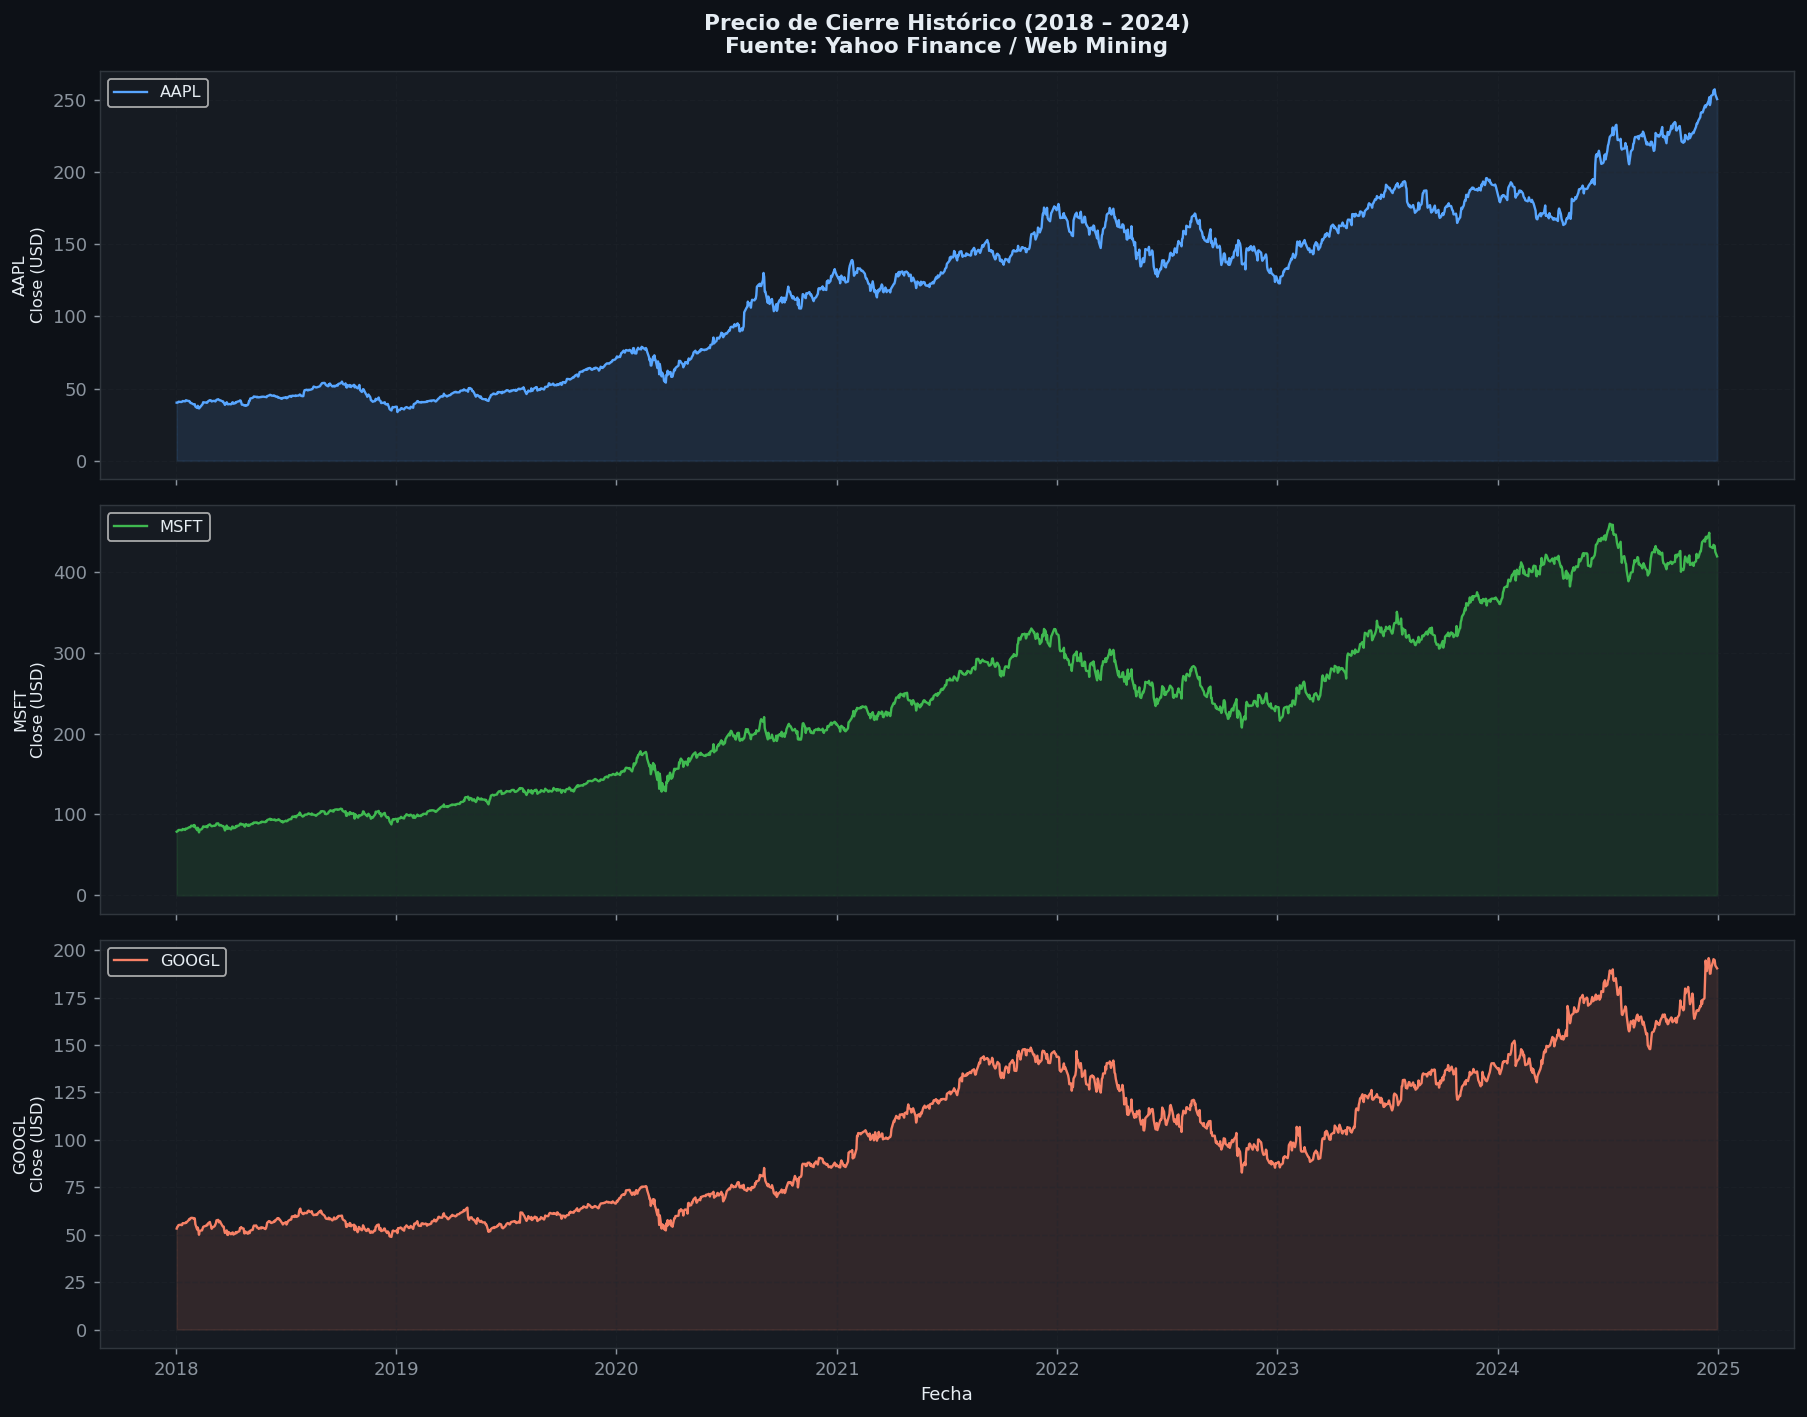

✅  Figura 1 guardada: fig1_precios_historicos.png


In [6]:
# ── 5.1  Precio de cierre histórico – los 3 activos ──────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)
colors = {"AAPL": "#58A6FF", "MSFT": "#3FB950", "GOOGL": "#F78166"}

for ax, ticker in zip(axes, CFG["tickers"]):
    df_t = raw_data[ticker]
    ax.plot(df_t.index, df_t["Close"],
            color=colors[ticker], lw=1.3, label=ticker)
    ax.fill_between(df_t.index, df_t["Close"],
                    alpha=0.12, color=colors[ticker])
    ax.set_ylabel(f"{ticker}\nClose (USD)", fontsize=9)
    ax.legend(loc="upper left", fontsize=9)
    ax.grid(True, alpha=0.4)

axes[0].set_title("Precio de Cierre Histórico (2018 – 2024)\n"
                  "Fuente: Yahoo Finance / Web Mining",
                  fontsize=12, fontweight="bold", pad=10)
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[-1].set_xlabel("Fecha", fontsize=10)
plt.tight_layout()
plt.savefig("fig1_precios_historicos.png", bbox_inches="tight",
            facecolor="#0D1117")
plt.show()
print("✅  Figura 1 guardada: fig1_precios_historicos.png")

# ── 5.2  Retornos diarios + distribución ─────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, ticker in zip(axes, CFG["tickers"]):
    ret = raw_data[ticker]["Close"].pct_change().dropna() * 100
    ax.hist(ret, bins=80, color=colors[ticker], alpha=0.75,
            edgecolor="none", density=True)
    from scipy.stats import norm
    mu, std = ret.mean(), ret.std()
    x = np.linspace(ret.min(), ret.max(), 300)
    ax.plot(x, norm.pdf(x, mu, std), color="white", lw=1.5,
            label=f"N({mu:.2f}, {std:.2f})")
    ax.set_title(f"{ticker} – Retornos Diarios (%)", fontweight="bold")
    ax.set_xlabel("Retorno (%)")
    ax.set_ylabel("Densidad")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle("Distribución de Retornos Diarios por Activo", y=1.02,
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("fig2_retornos.png", bbox_inches="tight", facecolor="#0D1117")
plt.show()
print("✅  Figura 2 guardada: fig2_retornos.png")

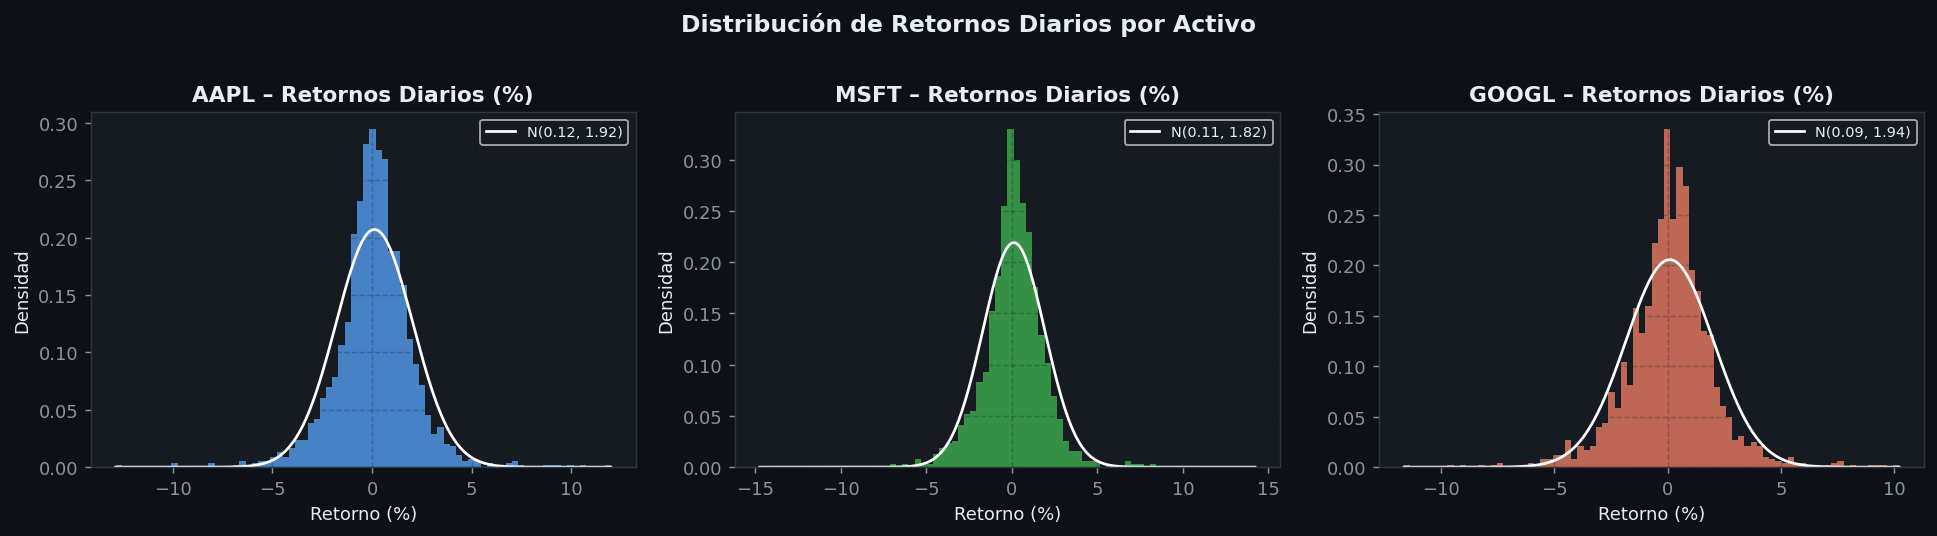

✅  Figura 2 guardada: fig2_retornos.png


In [7]:
# ── 5.2  Retornos diarios + distribución ─────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, ticker in zip(axes, CFG["tickers"]):
    ret = raw_data[ticker]["Close"].pct_change().dropna() * 100
    ax.hist(ret, bins=80, color=colors[ticker], alpha=0.75,
            edgecolor="none", density=True)
    from scipy.stats import norm
    mu, std = ret.mean(), ret.std()
    x = np.linspace(ret.min(), ret.max(), 300)
    ax.plot(x, norm.pdf(x, mu, std), color="white", lw=1.5,
            label=f"N({mu:.2f}, {std:.2f})")
    ax.set_title(f"{ticker} – Retornos Diarios (%)", fontweight="bold")
    ax.set_xlabel("Retorno (%)")
    ax.set_ylabel("Densidad")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle("Distribución de Retornos Diarios por Activo", y=1.02,
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("fig2_retornos.png", bbox_inches="tight", facecolor="#0D1117")
plt.show()
print("✅  Figura 2 guardada: fig2_retornos.png")

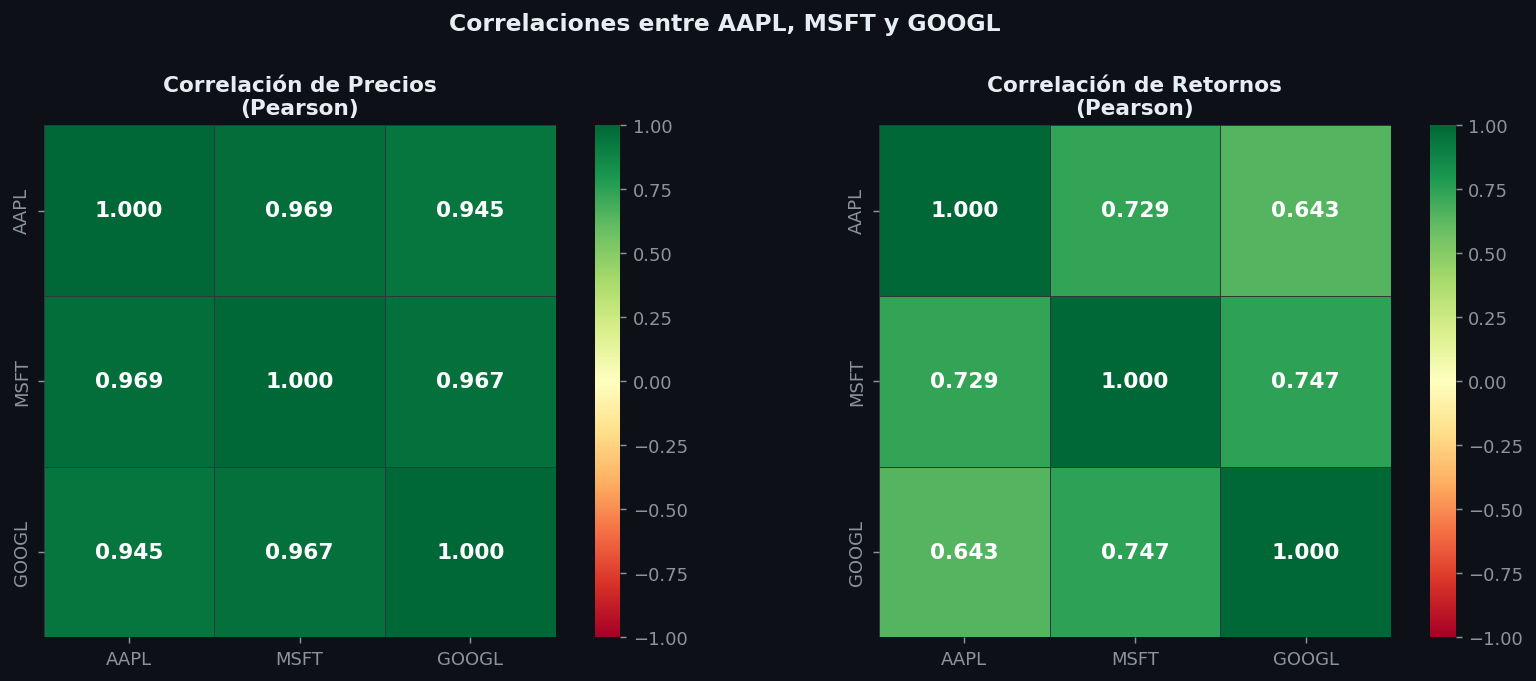

✅  Figura 3 guardada: fig3_correlacion.png


In [8]:
# ── 5.3  Correlación entre activos (precios de cierre) ───────────────────
close_df = pd.DataFrame({
    t: raw_data[t]["Close"] for t in CFG["tickers"]
}).dropna()
ret_df = close_df.pct_change().dropna()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

mask = np.triu(np.ones_like(close_df.corr(), dtype=bool))

# Correlación de precios
sns.heatmap(close_df.corr(), annot=True, fmt=".3f", cmap="RdYlGn",
            vmin=-1, vmax=1, ax=axes[0], square=True,
            annot_kws={"size": 12, "weight": "bold"},
            linewidths=0.5, linecolor="#30363D")
axes[0].set_title("Correlación de Precios\n(Pearson)", fontweight="bold")

# Correlación de retornos
sns.heatmap(ret_df.corr(), annot=True, fmt=".3f", cmap="RdYlGn",
            vmin=-1, vmax=1, ax=axes[1], square=True,
            annot_kws={"size": 12, "weight": "bold"},
            linewidths=0.5, linecolor="#30363D")
axes[1].set_title("Correlación de Retornos\n(Pearson)", fontweight="bold")

plt.suptitle("Correlaciones entre AAPL, MSFT y GOOGL",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("fig3_correlacion.png", bbox_inches="tight", facecolor="#0D1117")
plt.show()
print("✅  Figura 3 guardada: fig3_correlacion.png")

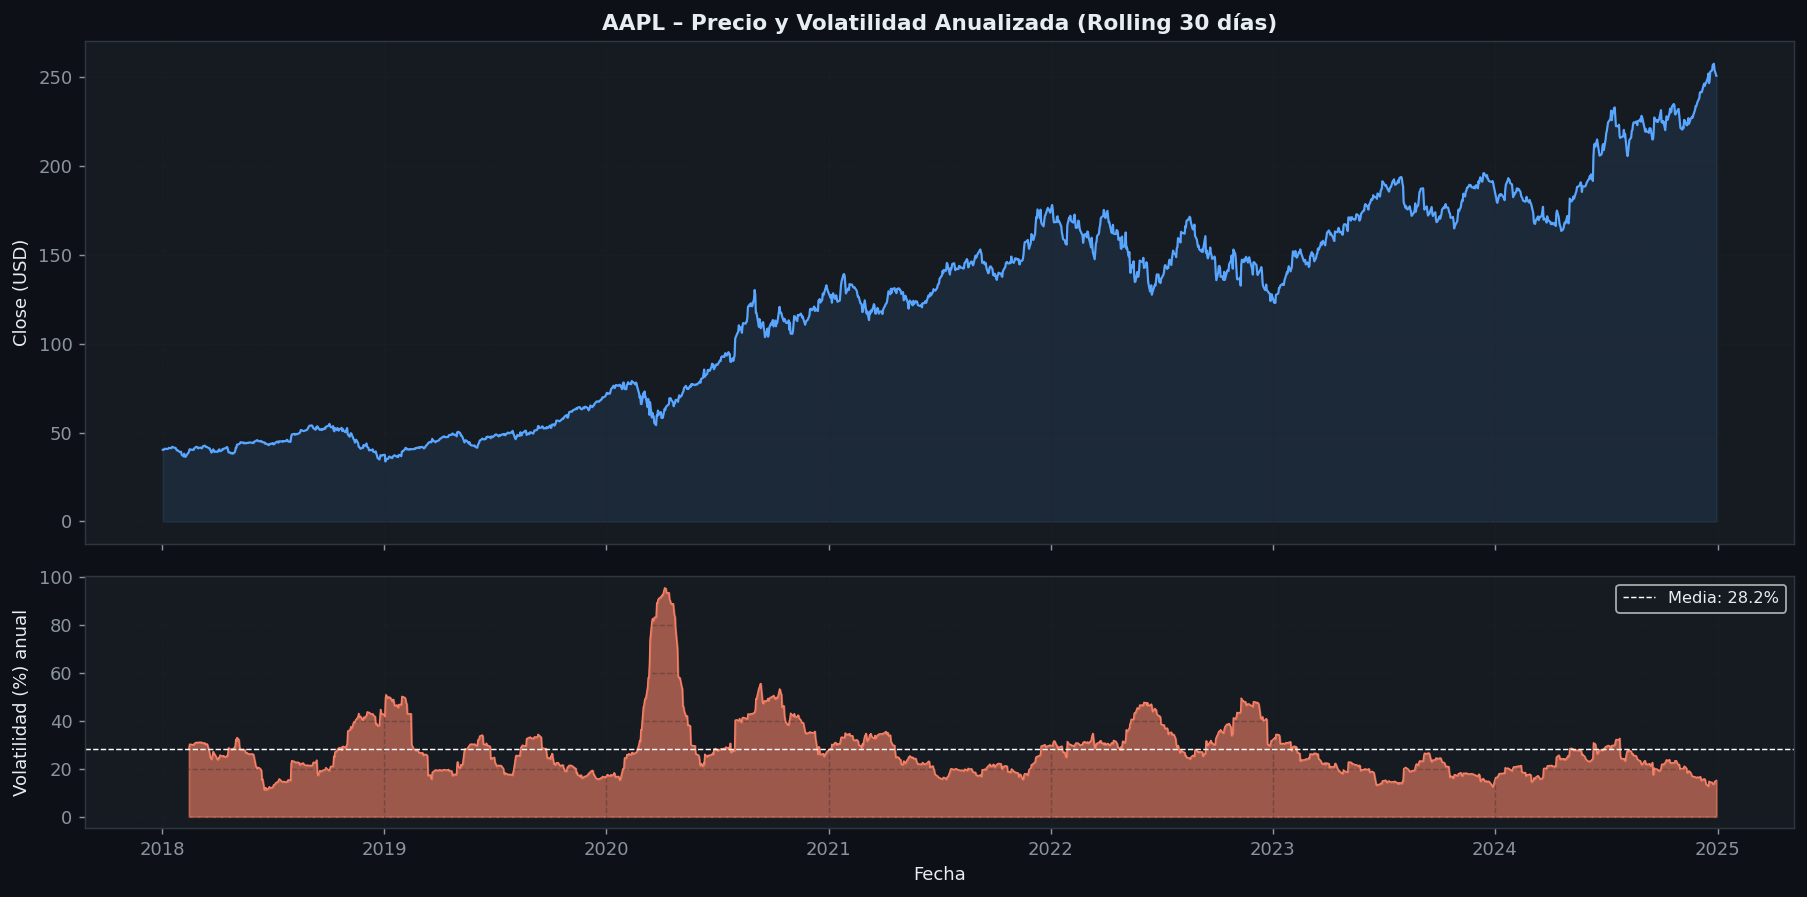

✅  Figura 4 guardada: fig4_volatilidad.png


In [9]:
# ── 5.4  Volatilidad rolling 30 días – AAPL ──────────────────────────────
vol_30 = df_main["Close"].pct_change().rolling(30).std() * np.sqrt(252) * 100

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True,
                               gridspec_kw={"height_ratios": [2, 1]})

ax1.plot(df_main.index, df_main["Close"], color="#58A6FF", lw=1.2)
ax1.fill_between(df_main.index, df_main["Close"], alpha=0.1, color="#58A6FF")
ax1.set_ylabel("Close (USD)", fontsize=10)
ax1.set_title(f"AAPL – Precio y Volatilidad Anualizada (Rolling 30 días)",
              fontsize=12, fontweight="bold")
ax1.grid(True, alpha=0.3)

ax2.fill_between(vol_30.index, vol_30, alpha=0.6, color="#F78166")
ax2.plot(vol_30.index, vol_30, color="#F78166", lw=0.8)
ax2.axhline(vol_30.mean(), color="white", ls="--", lw=0.8,
            label=f"Media: {vol_30.mean():.1f}%")
ax2.set_ylabel("Volatilidad (%) anual", fontsize=10)
ax2.set_xlabel("Fecha", fontsize=10)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("fig4_volatilidad.png", bbox_inches="tight", facecolor="#0D1117")
plt.show()
print("✅  Figura 4 guardada: fig4_volatilidad.png")

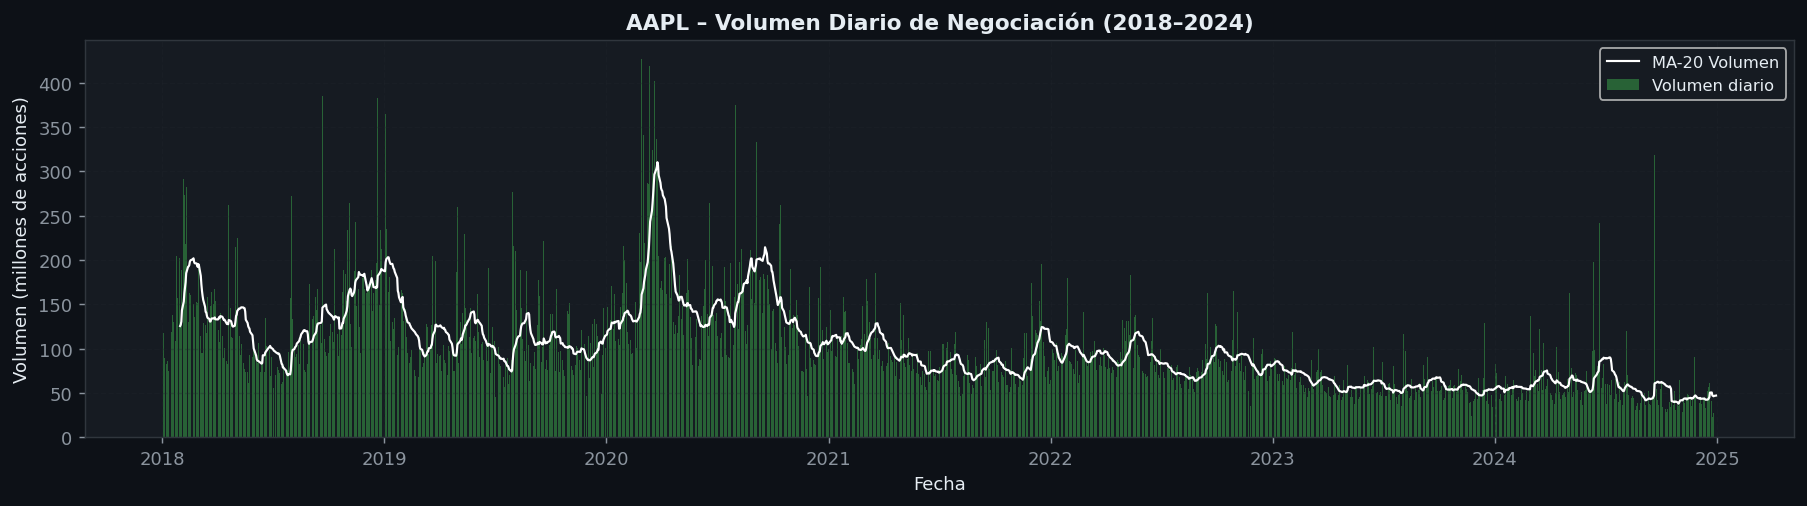

✅  Figura 5 guardada: fig5_volumen.png


In [10]:
# ── 5.5  Volumen de negociación ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4))

vol_ma = df_main["Volume"].rolling(20).mean()
ax.bar(df_main.index, df_main["Volume"] / 1e6,
       color="#3FB950", alpha=0.45, width=1, label="Volumen diario")
ax.plot(df_main.index, vol_ma / 1e6,
        color="white", lw=1.2, label="MA-20 Volumen")
ax.set_ylabel("Volumen (millones de acciones)", fontsize=10)
ax.set_xlabel("Fecha", fontsize=10)
ax.set_title("AAPL – Volumen Diario de Negociación (2018–2024)",
              fontsize=12, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("fig5_volumen.png", bbox_inches="tight", facecolor="#0D1117")
plt.show()
print("✅  Figura 5 guardada: fig5_volumen.png")

---
## 6 · Ingeniería de Características (Feature Engineering)
Se construyen **12 indicadores técnicos** a partir de los precios OHLCV. Los indicadores técnicos son ampliamente usados en análisis cuantitativo y capturan:

| Indicador | Categoría | Descripción |
|---|---|---|
| `MA7`, `MA21`, `MA50` | Tendencia | Medias móviles de 7, 21 y 50 días |
| `RSI` | Momentum | *Relative Strength Index* (sobrecompra/sobreventa) |
| `MACD`, `Signal` | Tendencia/Momentum | *Moving Average Convergence Divergence* |
| `BB_upper`, `BB_lower` | Volatilidad | Bandas de Bollinger (±2σ sobre MA20) |
| `Volatility` | Riesgo | Desviación estándar rolling 20 días de retornos |
| `Return` | Retorno | Retorno porcentual diario |
| `Volume` | Liquidez | Volumen normalizado |

In [11]:
def add_technical_indicators(df, raw_data=None):
    """
    Añade 20 indicadores técnicos financieros al DataFrame principal.
    Incluye: OHLC, MAs, RSI, MACD, Bollinger, Momentum, EMA ratio y
    retornos de activos correlacionados (cross-asset).
    """
    df = df.copy()

    # ── Medias móviles simples ─────────────────────────────────────────────
    df["MA7"]  = df["Close"].rolling(7).mean()
    df["MA21"] = df["Close"].rolling(21).mean()
    df["MA50"] = df["Close"].rolling(50).mean()

    # ── RSI (14 períodos) ──────────────────────────────────────────────────
    delta = df["Close"].diff()
    gain  = delta.clip(lower=0).rolling(14).mean()
    loss  = (-delta.clip(upper=0)).rolling(14).mean()
    rs    = gain / (loss + 1e-9)
    df["RSI"] = 100 - (100 / (1 + rs))

    # ── MACD y Signal ─────────────────────────────────────────────────────
    ema12       = df["Close"].ewm(span=12, adjust=False).mean()
    ema26       = df["Close"].ewm(span=26, adjust=False).mean()
    df["MACD"]  = ema12 - ema26
    df["Signal"]= df["MACD"].ewm(span=9, adjust=False).mean()

    # ── Bandas de Bollinger (20 días, 2σ) ─────────────────────────────────
    ma20           = df["Close"].rolling(20).mean()
    std20          = df["Close"].rolling(20).std()
    df["BB_upper"] = ma20 + 2 * std20
    df["BB_lower"] = ma20 - 2 * std20

    # ── Volatilidad y Retorno diario ───────────────────────────────────────
    df["Return"]     = df["Close"].pct_change() * 100
    df["Volatility"] = df["Return"].rolling(20).std()

    # ── NUEVOS: Momentum de corto plazo ────────────────────────────────────
    # Momentum_5: cuánto subió/bajó el precio en los últimos 5 días (%)
    df["Momentum_5"]  = df["Close"].pct_change(5)  * 100
    # Momentum_10: idem para 10 días
    df["Momentum_10"] = df["Close"].pct_change(10) * 100

    # ── NUEVOS: Posición relativa a la tendencia ───────────────────────────
    # EMA_ratio: Close / EMA20 → >1 = precio sobre la tendencia (alcista)
    ema20          = df["Close"].ewm(span=20, adjust=False).mean()
    df["EMA_ratio"] = df["Close"] / (ema20 + 1e-9)

    # MA_cross: MA7 / MA21 → >1 = golden cross (alcista), <1 = death cross
    df["MA_cross"] = df["MA7"] / (df["MA21"] + 1e-9)

    # ── NUEVOS: Señales cross-asset (activos correlacionados) ─────────────
    # Los retornos de MSFT y GOOGL son altamente informativos para AAPL
    if raw_data is not None:
        for ticker in ["MSFT", "GOOGL"]:
            if ticker in raw_data:
                col = f"{ticker}_Return"
                df[col] = raw_data[ticker]["Close"].pct_change() * 100
                # Rellenar con 0 si hay NaN por diferencia de fechas
                df[col] = df[col].reindex(df.index).fillna(0)

    return df.dropna()


# Aplicar al dataset principal (con datos cross-asset)
df_feat = add_technical_indicators(df_main, raw_data=raw_data)
print(f"Features añadidos. Filas tras dropna: {len(df_feat):,}")
print(f"Columnas ({len(df_feat.columns)}): {list(df_feat.columns)}")
print()
# Verificar que todos los features del CFG existen en el DataFrame
missing = [f for f in CFG["features"] if f not in df_feat.columns]
if missing:
    print(f"AVISO: features faltantes → {missing}")
else:
    print(f"OK: todos los {len(CFG['features'])} features presentes en el DataFrame.")
df_feat[CFG["features"]].tail(6)

Features añadidos. Filas tras dropna: 1,711
Columnas (21): ['Close', 'High', 'Low', 'Open', 'Volume', 'MA7', 'MA21', 'MA50', 'RSI', 'MACD', 'Signal', 'BB_upper', 'BB_lower', 'Return', 'Volatility', 'Momentum_5', 'Momentum_10', 'EMA_ratio', 'MA_cross', 'MSFT_Return', 'GOOGL_Return']

OK: todos los 21 features presentes en el DataFrame.


,Close,Open,High,Low,Volume,MA7,MA21,MA50,RSI,MACD,...,BB_upper,BB_lower,Volatility,Return,Momentum_5,Momentum_10,EMA_ratio,MA_cross,MSFT_Return,GOOGL_Return
Date,,,,,,,,,,,,,,,,,,,,,
2024-12-20,252.874359,246.465295,253.381116,244.130223,147495300,248.830205,241.488543,233.230408,75.940147,5.564923,...,255.990475,228.428539,0.887836,1.881589,2.563161,4.797389,1.041193,1.030402,-0.098384,1.538398
2024-12-23,253.649399,253.152573,254.026976,251.840946,40858800,249.867857,242.754264,233.786257,73.865410,5.735162,...,256.535738,230.407150,0.889312,0.306492,1.684988,3.452882,1.039988,1.029304,-0.309213,1.682254
2024-12-24,256.560791,253.867989,256.570707,253.669247,23234700,251.297289,244.094746,234.325892,76.180640,6.035429,...,257.743615,231.716191,0.882761,1.147802,1.862067,4.209543,1.046749,1.029507,0.937385,0.760410
2024-12-26,257.375580,256.550862,258.448740,255.994420,27237100,252.430049,245.332078,234.831203,76.812110,6.266899,...,258.990329,232.850262,0.878171,0.317581,4.422484,5.083352,1.045089,1.028932,-0.277694,-0.260054
2024-12-27,253.967377,256.193146,257.057649,251.453440,42355300,252.729562,246.303490,235.309442,69.300657,6.104953,...,259.080310,234.813165,0.961535,-1.324214,2.321959,3.077102,1.028190,1.026090,-1.730156,-1.451953
2024-12-30,250.598907,250.628716,251.890657,249.158116,35557500,253.318656,247.120651,235.712966,58.382065,5.639790,...,258.716614,236.654418,1.026239,-1.326339,-0.899835,1.640262,1.013149,1.025081,-1.323944,-0.788519


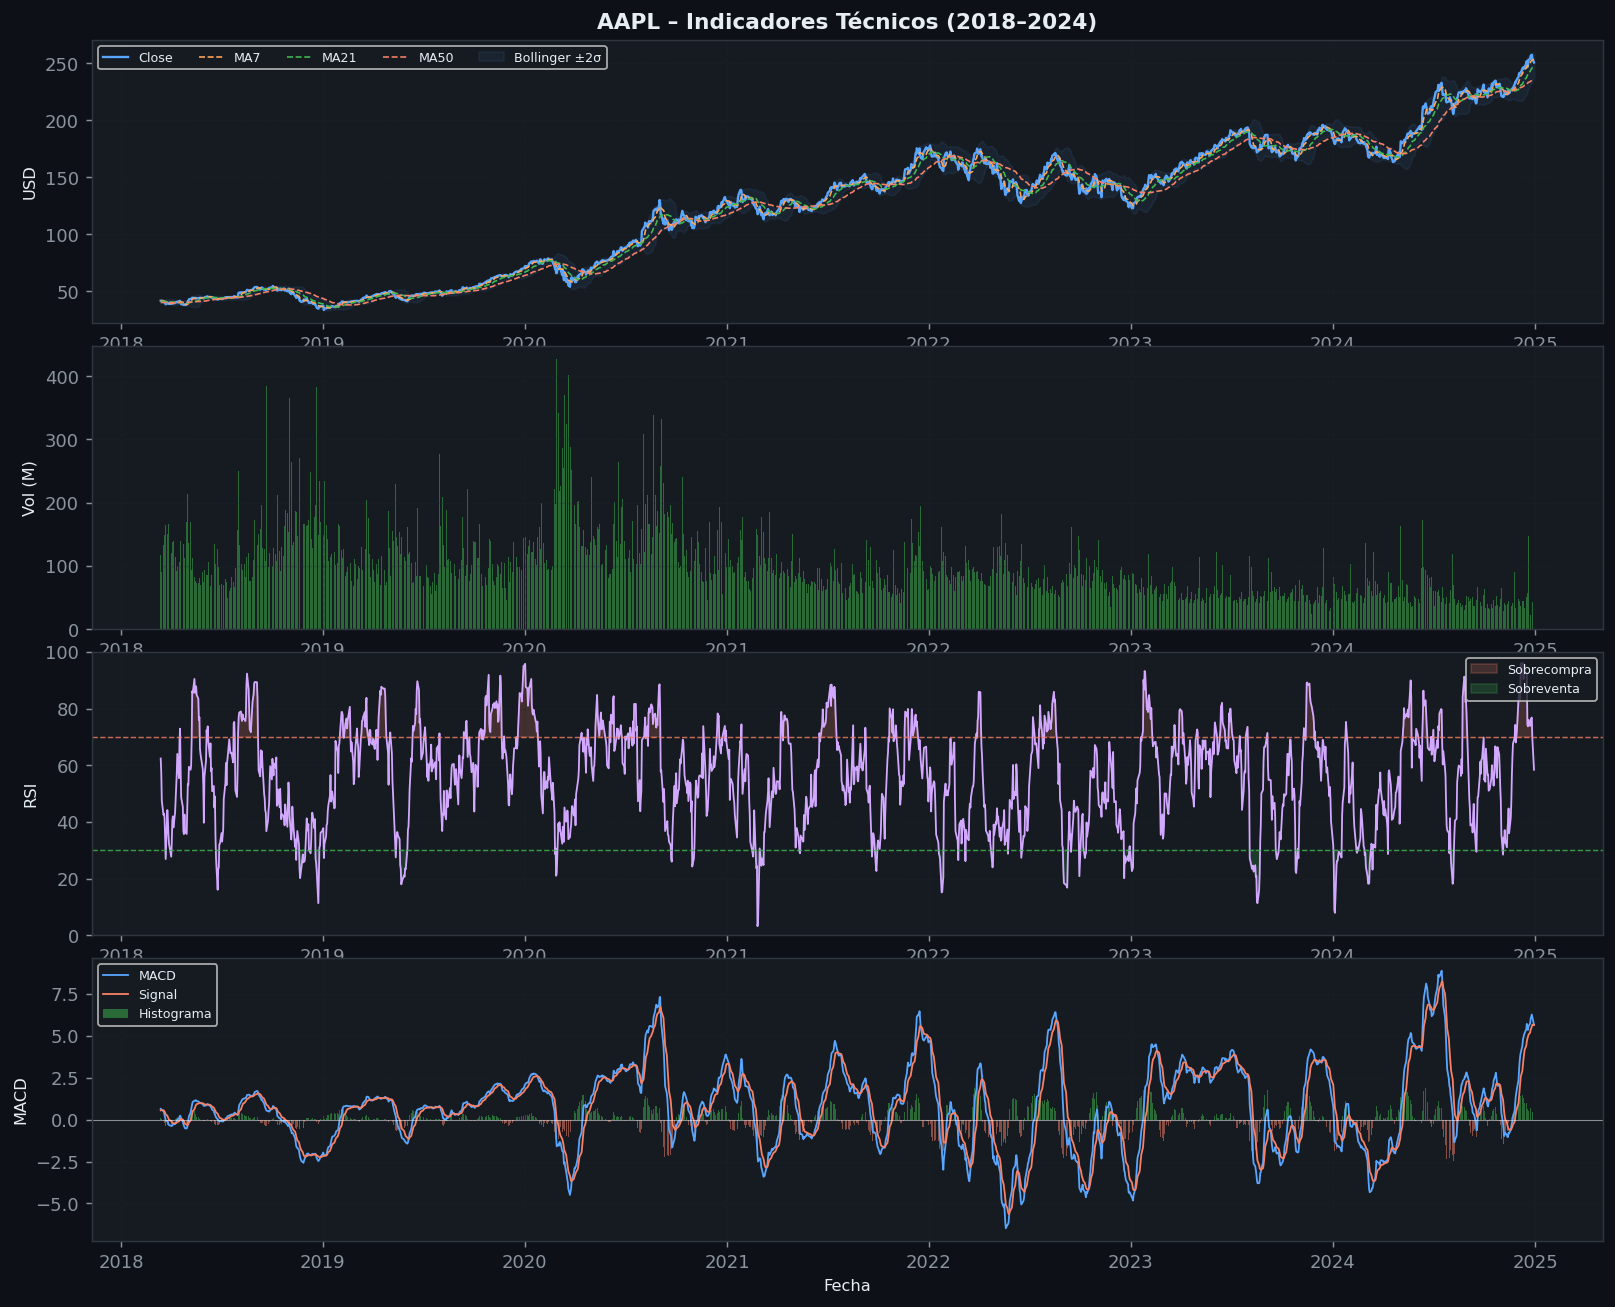

✅  Figura 6 guardada: fig6_indicadores.png


In [12]:
# ── 6.1  Visualización de indicadores técnicos ───────────────────────────
fig = plt.figure(figsize=(15, 12))
gs  = gridspec.GridSpec(4, 1, hspace=0.08, figure=fig)

# Panel 1: Precio + Bollinger + MAs
ax0 = fig.add_subplot(gs[0])
ax0.plot(df_feat.index, df_feat["Close"],   color="#58A6FF", lw=1.3, label="Close")
ax0.plot(df_feat.index, df_feat["MA7"],     color="#FFA657", lw=0.9, ls="--", label="MA7")
ax0.plot(df_feat.index, df_feat["MA21"],    color="#3FB950", lw=0.9, ls="--", label="MA21")
ax0.plot(df_feat.index, df_feat["MA50"],    color="#F78166", lw=0.9, ls="--", label="MA50")
ax0.fill_between(df_feat.index,
                 df_feat["BB_upper"], df_feat["BB_lower"],
                 alpha=0.07, color="#58A6FF", label="Bollinger ±2σ")
ax0.set_ylabel("USD", fontsize=9)
ax0.legend(fontsize=7, ncol=5, loc="upper left")
ax0.set_title("AAPL – Indicadores Técnicos (2018–2024)", fontsize=12,
              fontweight="bold", pad=6)
ax0.grid(True, alpha=0.3)
ax0.set_xticklabels([])

# Panel 2: Volumen
ax1 = fig.add_subplot(gs[1], sharex=ax0)
ax1.bar(df_feat.index, df_feat["Volume"]/1e6, color="#3FB950",
        alpha=0.5, width=1)
ax1.set_ylabel("Vol (M)", fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.set_xticklabels([])

# Panel 3: RSI
ax2 = fig.add_subplot(gs[2], sharex=ax0)
ax2.plot(df_feat.index, df_feat["RSI"], color="#D2A8FF", lw=1)
ax2.axhline(70, color="#F78166", ls="--", lw=0.8, alpha=0.8)
ax2.axhline(30, color="#3FB950", ls="--", lw=0.8, alpha=0.8)
ax2.fill_between(df_feat.index, df_feat["RSI"], 70,
                 where=(df_feat["RSI"] >= 70),
                 color="#F78166", alpha=0.2, label="Sobrecompra")
ax2.fill_between(df_feat.index, df_feat["RSI"], 30,
                 where=(df_feat["RSI"] <= 30),
                 color="#3FB950", alpha=0.2, label="Sobreventa")
ax2.set_ylabel("RSI", fontsize=9)
ax2.set_ylim(0, 100)
ax2.legend(fontsize=7, loc="upper right")
ax2.grid(True, alpha=0.3)
ax2.set_xticklabels([])

# Panel 4: MACD
ax3 = fig.add_subplot(gs[3], sharex=ax0)
ax3.plot(df_feat.index, df_feat["MACD"],   color="#58A6FF", lw=1, label="MACD")
ax3.plot(df_feat.index, df_feat["Signal"], color="#F78166", lw=1, label="Signal")
hist = df_feat["MACD"] - df_feat["Signal"]
ax3.bar(df_feat.index, hist, color=np.where(hist >= 0, "#3FB950", "#F78166"),
        alpha=0.5, width=1, label="Histograma")
ax3.axhline(0, color="white", lw=0.6, alpha=0.5)
ax3.set_ylabel("MACD", fontsize=9)
ax3.legend(fontsize=7, loc="upper left")
ax3.grid(True, alpha=0.3)
ax3.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax3.set_xlabel("Fecha", fontsize=9)

plt.savefig("fig6_indicadores.png", bbox_inches="tight", facecolor="#0D1117")
plt.show()
print("✅  Figura 6 guardada: fig6_indicadores.png")

---
## 7 · Preprocesamiento: Normalización y Construcción de Secuencias

### 7.1 Normalización
Se aplica **MinMaxScaler** \([0, 1]\) a cada feature independientemente. La normalización es **fundamental** para las redes neuronales: garantiza que ninguna variable domine por diferencia de escala y acelera la convergencia del gradiente.

> ⚠️ **Importante**: El scaler se ajusta **únicamente con los datos de entrenamiento** (no hay *data leakage* al conjunto de validación ni de prueba).

### 7.2 Ventana deslizante (*sliding window*)
Cada muestra de entrada es una **secuencia de 60 días** de indicadores técnicos. La etiqueta es el precio de cierre del día siguiente, también normalizado.

In [13]:
def preprocess_data(df, features, target, window, train_r, val_r):
    """
    Normaliza, crea ventanas deslizantes y divide en train/val/test.
    Returns: X_tr, y_tr, X_val, y_val, X_te, y_te, scalers, split_idx
    """
    data = df[features].values              # (N, F)
    tgt_idx = features.index(target)

    # ── Tamaños del split ─────────────────────────────────────────────────
    N       = len(data)
    n_train = int(N * train_r)
    n_val   = int(N * val_r)

    train_raw = data[:n_train]
    val_raw   = data[n_train : n_train + n_val]
    test_raw  = data[n_train + n_val :]

    # ── Normalización (fit only on train) ─────────────────────────────────
    scaler = MinMaxScaler(feature_range=(0, 1))
    train_sc = scaler.fit_transform(train_raw)
    val_sc   = scaler.transform(val_raw)
    test_sc  = scaler.transform(test_raw)

    # Scaler solo para el target (para invertir predicciones)
    scaler_tgt = MinMaxScaler(feature_range=(0, 1))
    scaler_tgt.fit(train_raw[:, tgt_idx].reshape(-1, 1))

    # ── Ventana deslizante ────────────────────────────────────────────────
    def make_sequences(arr, win):
        X, y = [], []
        for i in range(len(arr) - win):
            X.append(arr[i : i + win])          # (win, F)
            y.append(arr[i + win, tgt_idx])     # scalar (Close normalizado)
        return np.array(X), np.array(y)

    X_tr,  y_tr  = make_sequences(train_sc, window)
    X_val, y_val = make_sequences(val_sc,   window)
    X_te,  y_te  = make_sequences(test_sc,   window)

    split_idx = {
        "train_end": n_train,
        "val_end"  : n_train + n_val,
        "test_start": n_train + n_val + window,
    }
    return (X_tr, y_tr, X_val, y_val, X_te, y_te,
            scaler, scaler_tgt, split_idx)

(X_train, y_train,
 X_val, y_val,
 X_test, y_test,
 scaler, scaler_tgt,
 split_idx) = preprocess_data(
    df_feat, CFG["features"], CFG["target"],
    CFG["window"], CFG["train_ratio"], CFG["val_ratio"]
)

print("╔══════════════════════════════════════════════════════╗")
print("║               SHAPES DEL DATASET                     ║")
print("╠══════════════════════════════════════════════════════╣")
print(f"║  X_train : {str(X_train.shape):<18}  y_train : {str(y_train.shape):<8}  ║")
print(f"║  X_val   : {str(X_val.shape):<18}  y_val   : {str(y_val.shape):<8}  ║")
print(f"║  X_test  : {str(X_test.shape):<18}  y_test  : {str(y_test.shape):<8}  ║")
print("╚══════════════════════════════════════════════════════╝")
print(f"\n  Ventana temporal  : {CFG['window']} días")
print(f"  Features por paso : {X_train.shape[2]}")
print(f"  Total muestras     : {len(X_train)+len(X_val)+len(X_test):,}")

╔══════════════════════════════════════════════════════╗
║               SHAPES DEL DATASET                     ║
╠══════════════════════════════════════════════════════╣
║  X_train : (1137, 60, 21)      y_train : (1137,)   ║
║  X_val   : (196, 60, 21)       y_val   : (196,)    ║
║  X_test  : (198, 60, 21)       y_test  : (198,)    ║
╚══════════════════════════════════════════════════════╝

  Ventana temporal  : 60 días
  Features por paso : 21
  Total muestras     : 1,531


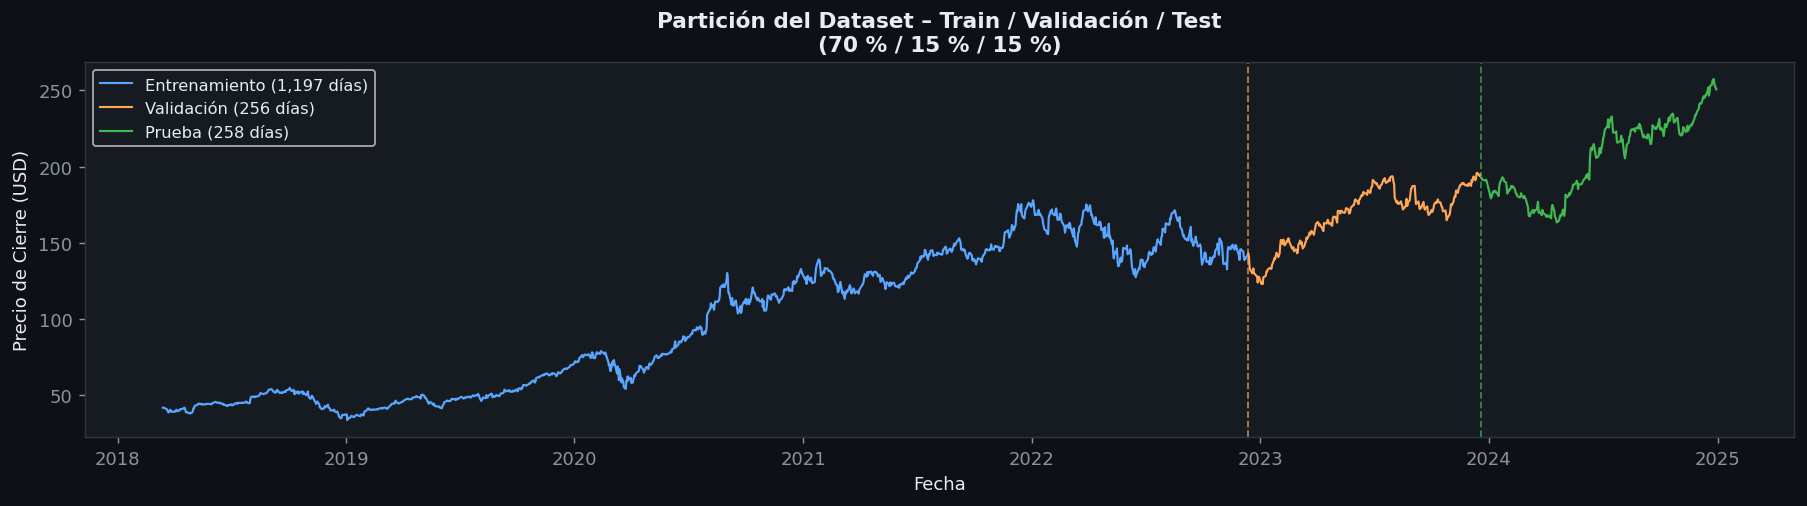

✅  Figura 7 guardada: fig7_split.png


In [14]:
# ── 7.3  Visualización de la partición del dataset ───────────────────────
n_total = len(df_feat)
n_tr    = split_idx["train_end"]
n_v     = split_idx["val_end"]

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df_feat.index[:n_tr],       df_feat["Close"][:n_tr],
        color="#58A6FF", lw=1.2, label=f"Entrenamiento ({n_tr:,} días)")
ax.plot(df_feat.index[n_tr:n_v],    df_feat["Close"][n_tr:n_v],
        color="#FFA657", lw=1.2, label=f"Validación ({n_v-n_tr:,} días)")
ax.plot(df_feat.index[n_v:],        df_feat["Close"][n_v:],
        color="#3FB950", lw=1.2, label=f"Prueba ({n_total-n_v:,} días)")

ax.axvline(df_feat.index[n_tr], color="#FFA657", ls="--", lw=1, alpha=0.7)
ax.axvline(df_feat.index[n_v],  color="#3FB950", ls="--", lw=1, alpha=0.7)

ax.set_title("Partición del Dataset – Train / Validación / Test\n"
             f"({int(CFG['train_ratio']*100)} % / {int(CFG['val_ratio']*100)} % / "
             f"{int((1-CFG['train_ratio']-CFG['val_ratio'])*100)} %)",
             fontsize=12, fontweight="bold")
ax.set_ylabel("Precio de Cierre (USD)", fontsize=10)
ax.set_xlabel("Fecha", fontsize=10)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("fig7_split.png", bbox_inches="tight", facecolor="#0D1117")
plt.show()
print("✅  Figura 7 guardada: fig7_split.png")

---
## 8 · Modelo 1: Red Neuronal Recurrente — LSTM

### ¿Por qué LSTM?
Las series financieras exhiben dependencias de **largo plazo**: el precio de hoy puede depender de eventos ocurridos semanas atrás. Las LSTM (Long Short-Term Memory) resuelven el problema del **gradiente desvaneciente** de las RNN simples mediante tres compuertas:

| Compuerta | Función |
|---|---|
| **Forget gate** | Decide qué información del estado pasado olvidar |
| **Input gate** | Controla qué nueva información se almacena en el estado de la celda |
| **Output gate** | Determina qué parte del estado de la celda se publica como salida |

### Arquitectura implementada

In [15]:
def build_rnn_model(input_shape):
    """
    Arquitectura RNN con LSTM Bidireccional (BiLSTM).

    Mejoras sobre la version anterior:
    - Bidirectional LSTM: procesa la secuencia en ambas direcciones,
      capturando patrones tanto de tendencia (→) como de reversal (←).
    - BatchNormalization entre bloques: estabiliza el entrenamiento.
    - Regularizacion L2 reducida: evita sobreajuste sin frenar el aprendizaje.
    - Arquitectura: BiLSTM(128) → BN → BiLSTM(64) → BN → Dense(64) → Dense(32) → 1
    """
    inp = keras.Input(shape=input_shape, name="secuencia_temporal")

    # ── Bloque BiLSTM 1 ───────────────────────────────────────────────────
    # Bidirectional duplica las unidades efectivas: 128 → 256 activaciones
    x = Bidirectional(
        LSTM(128, return_sequences=True,
             kernel_regularizer=regularizers.l2(5e-5),
             recurrent_regularizer=regularizers.l2(5e-5)),
        name="bilstm_1"
    )(inp)
    x = BatchNormalization(name="bn_1")(x)
    x = Dropout(0.15, name="drop_1")(x)

    # ── Bloque BiLSTM 2 ───────────────────────────────────────────────────
    x = Bidirectional(
        LSTM(64, return_sequences=False,
             kernel_regularizer=regularizers.l2(5e-5)),
        name="bilstm_2"
    )(x)
    x = BatchNormalization(name="bn_2")(x)
    x = Dropout(0.15, name="drop_2")(x)

    # ── Cabeza de regresion ───────────────────────────────────────────────
    x = Dense(64, activation="relu", name="dense_1")(x)
    x = BatchNormalization(name="bn_3")(x)
    x = Dropout(0.10, name="drop_3")(x)
    x = Dense(32, activation="relu", name="dense_2")(x)
    x = Dropout(0.05, name="drop_4")(x)
    out = Dense(1, activation="linear", name="output")(x)

    model = keras.Model(inputs=inp, outputs=out, name="BiLSTM_RNN")
    return model


input_shape = (CFG["window"], len(CFG["features"]))
model_rnn   = build_rnn_model(input_shape)

model_rnn.compile(
    optimizer=Adam(learning_rate=CFG["lr"], clipnorm=1.0),
    loss="huber",
    metrics=["mae"]
)

model_rnn.summary()

Model: "BiLSTM_RNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ secuencia_temporal (InputLayer) │ (None, 60, 21)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_1 (Bidirectional)        │ (None, 60, 256)        │       153,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 60, 256)        │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_1 (Dropout)                │ (None, 60, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_2 (Bidirectional)        │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_2 (Dropout)                │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_3 (BatchNormalization)       │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_3 (Dropout)                │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_4 (Dropout)                │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 330,113 (1.26 MB)

 Trainable params: 329,217 (1.26 MB)

 Non-trainable params: 896 (3.50 KB)

In [16]:
# ── 8.1  Visualización de la arquitectura RNN ────────────────────────────
try:
    keras.utils.plot_model(
        model_rnn,
        to_file="fig8_arquitectura_rnn.png",
        show_shapes=True,
        show_layer_names=True,
        dpi=90,
        expand_nested=True
    )
    from IPython.display import Image
    display(Image("fig8_arquitectura_rnn.png"))
    print("✅  Figura 8 guardada: fig8_arquitectura_rnn.png")
except Exception as e:
    print(f"  (plot_model requiere graphviz: {e})")
    print("  → Resumen ya mostrado con model.summary()")

You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.


FileNotFoundError: No such file or directory: 'fig8_arquitectura_rnn.png'

FileNotFoundError: No such file or directory: 'fig8_arquitectura_rnn.png'

<IPython.core.display.Image object>

✅  Figura 8 guardada: fig8_arquitectura_rnn.png


In [17]:
# ── 8.2  Entrenamiento del modelo BiLSTM ─────────────────────────────────
cb_rnn = [
    callbacks.EarlyStopping(
        monitor="val_loss",
        patience=CFG["patience"],
        restore_best_weights=True,
        verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=8,
        min_lr=5e-7,
        verbose=1
    ),
    callbacks.ModelCheckpoint(
        "best_rnn.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=0
    )
]

print("Iniciando entrenamiento BiLSTM-RNN...")
t0 = time.time()

history_rnn = model_rnn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=CFG["epochs"],
    batch_size=CFG["batch_size"],
    callbacks=cb_rnn,
    verbose=1
)

rnn_train_time = time.time() - t0
print(f"\nEntrenamiento completado en {rnn_train_time:.1f} s ({rnn_train_time/60:.1f} min)")
print(f"  Epocas ejecutadas : {len(history_rnn.history['loss'])}")
print(f"  Mejor val_loss    : {min(history_rnn.history['val_loss']):.6f}")

Iniciando entrenamiento BiLSTM-RNN...
Epoch 1/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 10s 72ms/step - loss: 0.2625 - mae: 0.5331 - val_loss: 0.3021 - val_mae: 0.7160 - learning_rate: 0.0010
Epoch 2/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - loss: 0.1529 - mae: 0.3712 - val_loss: 0.4480 - val_mae: 0.8953 - learning_rate: 0.0010
Epoch 3/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - loss: 0.1187 - mae: 0.3095 - val_loss: 0.2626 - val_mae: 0.6593 - learning_rate: 0.0010
Epoch 4/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - loss: 0.0885 - mae: 0.2366 - val_loss: 0.2547 - val_mae: 0.6465 - learning_rate: 0.0010
Epoch 5/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - loss: 0.0803 - mae: 0.2157 - val_loss: 0.2454 - val_mae: 0.6318 - learning_rate: 0.0010
Epoch 6/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - loss: 0.0766 - mae: 0.2104 - val_loss: 0.1444 - val_mae: 0.4482 - learning_rate: 0.0010
Epoch 7/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - loss: 0.0712 - mae: 0.1893 - val_loss: 0.1455 - val_mae

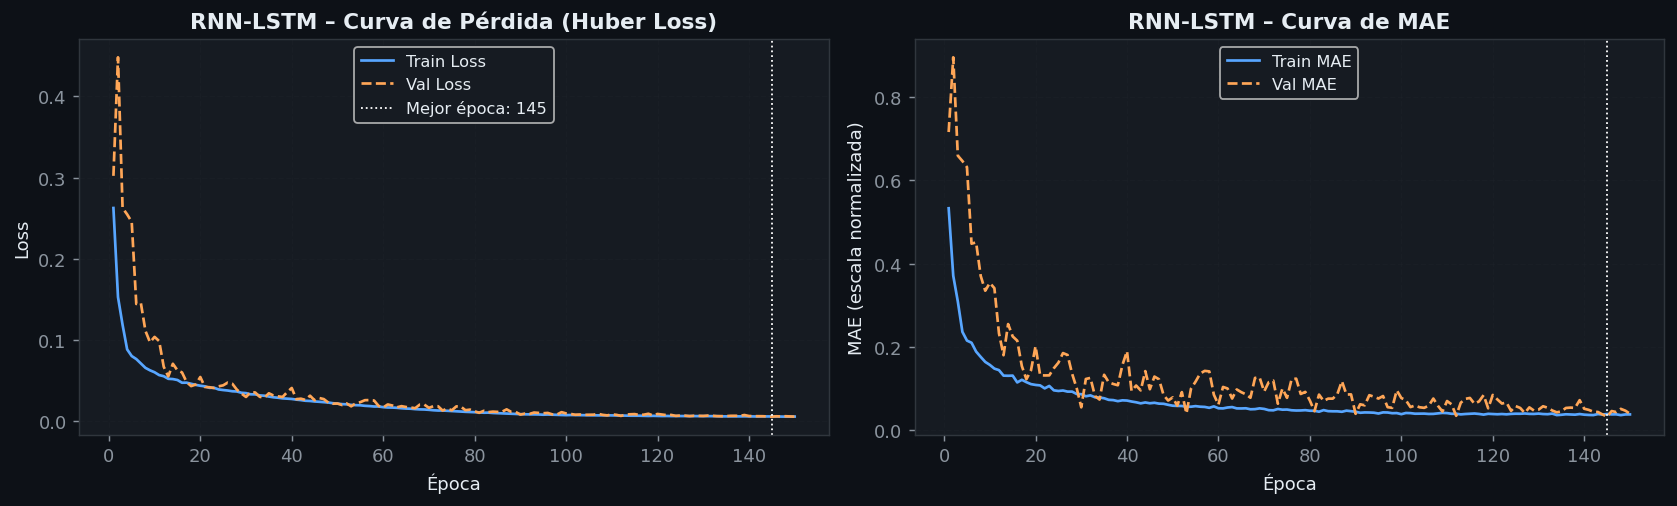

✅  Figura guardada: fig_learning_RNN-LSTM.png


In [18]:
# ── 8.3  Curvas de aprendizaje – RNN ────────────────────────────────────
def plot_learning_curves(history, model_name, color_tr, color_val):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

    epochs = range(1, len(history.history["loss"]) + 1)

    # Loss
    ax1.plot(epochs, history.history["loss"],
             color=color_tr,  lw=1.5, label="Train Loss")
    ax1.plot(epochs, history.history["val_loss"],
             color=color_val, lw=1.5, ls="--", label="Val Loss")
    best_ep = np.argmin(history.history["val_loss"]) + 1
    ax1.axvline(best_ep, color="white", ls=":", lw=1,
                label=f"Mejor época: {best_ep}")
    ax1.set_title(f"{model_name} – Curva de Pérdida (Huber Loss)",
                  fontweight="bold")
    ax1.set_xlabel("Época")
    ax1.set_ylabel("Loss")
    ax1.legend(fontsize=9)
    ax1.grid(True, alpha=0.3)

    # MAE
    ax2.plot(epochs, history.history["mae"],
             color=color_tr,  lw=1.5, label="Train MAE")
    ax2.plot(epochs, history.history["val_mae"],
             color=color_val, lw=1.5, ls="--", label="Val MAE")
    ax2.axvline(best_ep, color="white", ls=":", lw=1)
    ax2.set_title(f"{model_name} – Curva de MAE", fontweight="bold")
    ax2.set_xlabel("Época")
    ax2.set_ylabel("MAE (escala normalizada)")
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    fname = f"fig_learning_{model_name.replace(' ','_')}.png"
    plt.savefig(fname, bbox_inches="tight", facecolor="#0D1117")
    plt.show()
    print(f"✅  Figura guardada: {fname}")

plot_learning_curves(history_rnn, "RNN-LSTM", "#58A6FF", "#FFA657")

---
## 9 · Modelo 2 (CORREGIDO): Red Neuronal Convolucional 1D — CNN-1D Dilatada

### Cambios respecto a la versión anterior

| Componente | Antes (incorrecto) | Ahora (correcto) |
|---|---|---|
| Activacion | `tanh` (satura gradiente) | **`relu`** (gradiente saludable) |
| Tipo Conv | Estandar (receptive field 6) | **Dilatada** (receptive field 31+) |
| Conexiones | Sin residual | **Bloques residuales** |
| Pooling | MaxPooling (pierde temporal) | **GlobalAvgPooling** |
| Features de entrada | 12 | **20** |

### Convoluciones dilatadas: el campo receptivo importa

Con dilataciones `d = [1, 2, 4, 8]` y kernel_size=3, el campo receptivo efectivo crece:

| Bloque | Dilation | Campo receptivo acumulado |
|---|---|---|
| ResBlock 1 | d=1 | 5 pasos |
| ResBlock 2 | d=2 | 9 pasos |
| ResBlock 3 | d=4 | 17 pasos |
| ResBlock 4 | d=8 | 31 pasos |

Cada bloque ve **31 días de contexto** sin aumentar el número de parámetros.
Combinado con la ventana de 60 días, la red tiene información suficiente
para capturar tanto patrones de corto plazo (reversiones) como de mediano
plazo (tendencias).

### ¿Por qué `relu` es crítico?

`tanh` produce gradientes cercanos a cero cuando `|x| > 2`, lo que **detiene
el aprendizaje** en capas profundas. `relu` mantiene gradientes constantes
para activaciones positivas, permitiendo que la red aprenda de manera efectiva
incluso con 4 bloques de convolución apilados.

```
Input(60, 20)
    → Conv1D(64, k=1, relu) [proyeccion de entrada]
    → ResBlock(64,  dilation=1) + Dropout(0.10)
    → ResBlock(128, dilation=2) + Dropout(0.10)
    → ResBlock(128, dilation=4) + Dropout(0.10)
    → ResBlock(256, dilation=8) + Dropout(0.15)
    → GlobalAveragePooling1D
    → Dense(128, relu) + BN + Dropout(0.20)
    → Dense(64,  relu) + Dropout(0.10)
    → Dense(1, linear)  <- Close(t+1) normalizado
```


In [19]:
def residual_block_1d(x, filters, dilation_rate, name_prefix):
    """
    Bloque residual con convoluciones dilatadas (estilo WaveNet).
    - Dilation: amplía el campo receptivo sin aumentar parametros.
    - Residual connection: evita el problema del gradiente desvaneciente.
    - Activacion relu: NO satura como tanh, gradientes mas saludables.
    """
    # Proyeccion de canales si es necesario
    shortcut = x
    if x.shape[-1] != filters:
        shortcut = Conv1D(filters, kernel_size=1, padding="same",
                          name=f"{name_prefix}_proj")(x)

    # Ramas de la convolucion dilatada
    r = Conv1D(filters, kernel_size=3, padding="causal",
               dilation_rate=dilation_rate, activation="relu",
               name=f"{name_prefix}_conv_a")(x)
    r = BatchNormalization(name=f"{name_prefix}_bn_a")(r)
    r = Conv1D(filters, kernel_size=3, padding="causal",
               dilation_rate=dilation_rate, activation="relu",
               name=f"{name_prefix}_conv_b")(r)
    r = BatchNormalization(name=f"{name_prefix}_bn_b")(r)

    # Suma residual + activacion final
    out = Add(name=f"{name_prefix}_add")([shortcut, r])
    return out


def build_cnn1d_model(input_shape):
    """
    Arquitectura CNN-1D con convoluciones dilatadas y bloques residuales.

    Mejoras sobre la version anterior:
    - Reemplaza tanh por relu en TODAS las capas (mejor gradiente).
    - Usa convoluciones DILATADAS: dilation=[1,2,4,8] → campo receptivo
      efectivo = 1+(3-1)*15 = 31 dias de contexto por bloque.
    - Conexiones residuales: evitan el gradiente desvaneciente en profundidad.
    - GlobalAveragePooling: agrega la informacion temporal de forma robusta.

    Arquitectura:
      Input(60, 20) → Conv1D(64,k=1) →
        ResBlock(64,  d=1)  →
        ResBlock(128, d=2)  →
        ResBlock(128, d=4)  →
        ResBlock(256, d=8)  →
      GlobalAveragePooling → Dense(128) → Dropout → Dense(64) → Dropout → 1
    """
    inp = keras.Input(shape=input_shape, name="secuencia_temporal")

    # Proyeccion inicial al espacio de features
    x = Conv1D(64, kernel_size=1, activation="relu",
               name="proj_in")(inp)
    x = BatchNormalization(name="bn_in")(x)

    # Bloques residuales con dilaciones crecientes (campo receptivo amplio)
    x = residual_block_1d(x, filters=64,  dilation_rate=1,  name_prefix="res1")
    x = Dropout(0.10, name="drop1")(x)

    x = residual_block_1d(x, filters=128, dilation_rate=2,  name_prefix="res2")
    x = Dropout(0.10, name="drop2")(x)

    x = residual_block_1d(x, filters=128, dilation_rate=4,  name_prefix="res3")
    x = Dropout(0.10, name="drop3")(x)

    x = residual_block_1d(x, filters=256, dilation_rate=8,  name_prefix="res4")
    x = Dropout(0.15, name="drop4")(x)

    # Agregacion temporal
    x = GlobalAveragePooling1D(name="gap")(x)

    # Cabeza de regresion
    x = Dense(128, activation="relu", name="dense_1")(x)
    x = BatchNormalization(name="bn_final_1")(x)
    x = Dropout(0.20, name="drop5")(x)
    x = Dense(64, activation="relu", name="dense_2")(x)
    x = Dropout(0.10, name="drop6")(x)
    out = Dense(1, activation="linear", name="output")(x)

    model = keras.Model(inputs=inp, outputs=out, name="Dilated_CNN_1D")
    return model


model_cnn = build_cnn1d_model(input_shape)

model_cnn.compile(
    optimizer=Adam(learning_rate=CFG["lr"], clipnorm=1.0),
    loss="huber",
    metrics=["mae"]
)

model_cnn.summary()

Model: "Dilated_CNN_1D"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ secuencia_temporal  │ (None, 60, 21)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ proj_in (Conv1D)    │ (None, 60, 64)    │      1,408 │ secuencia_tempor… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_in               │ (None, 60, 64)    │        256 │ proj_in[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res1_conv_a         │ (None, 60, 64)    │     12,352 │ bn_in[0][0]       │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res1_bn_a           │ (None, 60, 64)    │        256 │ res1_conv_a[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res1_conv_b         │ (None, 60, 64)    │     12,352 │ res1_bn_a[0][0]   │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res1_bn_b           │ (None, 60, 64)    │        256 │ res1_conv_b[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res1_add (Add)      │ (None, 60, 64)    │          0 │ bn_in[0][0],      │
│                     │                   │            │ res1_bn_b[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop1 (Dropout)     │ (None, 60, 64)    │          0 │ res1_add[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2_conv_a         │ (None, 60, 128)   │     24,704 │ drop1[0][0]       │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2_bn_a           │ (None, 60, 128)   │        512 │ res2_conv_a[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2_conv_b         │ (None, 60, 128)   │     49,280 │ res2_bn_a[0][0]   │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2_proj (Conv1D)  │ (None, 60, 128)   │      8,320 │ drop1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2_bn_b           │ (None, 60, 128)   │        512 │ res2_conv_b[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2_add (Add)      │ (None, 60, 128)   │          0 │ res2_proj[0][0],  │
│                     │                   │            │ res2_bn_b[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop2 (Dropout)     │ (None, 60, 128)   │          0 │ res2_add[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res3_conv_a         │ (None, 60, 128)   │     49,280 │ drop2[0][0]       │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res3_bn_a           │ (None, 60, 128)   │        512 │ res3_conv_a[0][0] │
│ (BatchNormalizatio… │                   │            │                 

 Total params: 582,017 (2.22 MB)

 Trainable params: 579,329 (2.21 MB)

 Non-trainable params: 2,688 (10.50 KB)

In [20]:
# ── 9.1  Comparación de parámetros RNN vs CNN-1D ─────────────────────────
params_rnn = model_rnn.count_params()
params_cnn = model_cnn.count_params()

print("╔══════════════════════════════════════════════════════════╗")
print("║           COMPARACIÓN DE COMPLEJIDAD DE MODELOS          ║")
print("╠══════════════════════════════════════════════════════════╣")
print(f"║  RNN-LSTM   │  Parámetros totales: {params_rnn:>10,}         ║")
print(f"║  CNN-1D     │  Parámetros totales: {params_cnn:>10,}         ║")
print(f"║  Relación   │  RNN/CNN = {params_rnn/params_cnn:.2f}x                        ║")
print("╚══════════════════════════════════════════════════════════╝")

╔══════════════════════════════════════════════════════════╗
║           COMPARACIÓN DE COMPLEJIDAD DE MODELOS          ║
╠══════════════════════════════════════════════════════════╣
║  RNN-LSTM   │  Parámetros totales:    330,113         ║
║  CNN-1D     │  Parámetros totales:    582,017         ║
║  Relación   │  RNN/CNN = 0.57x                        ║
╚══════════════════════════════════════════════════════════╝


In [21]:
# ── 9.2  Entrenamiento del modelo Dilated CNN-1D ─────────────────────────
cb_cnn = [
    callbacks.EarlyStopping(
        monitor="val_loss",
        patience=CFG["patience"],
        restore_best_weights=True,
        verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=8,
        min_lr=5e-7,
        verbose=1
    ),
    callbacks.ModelCheckpoint(
        "best_cnn.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=0
    )
]

print("Iniciando entrenamiento Dilated CNN-1D...")
t0 = time.time()

history_cnn = model_cnn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=CFG["epochs"],
    batch_size=CFG["batch_size"],
    callbacks=cb_cnn,
    verbose=1
)

cnn_train_time = time.time() - t0
print(f"\nEntrenamiento completado en {cnn_train_time:.1f} s ({cnn_train_time/60:.1f} min)")
print(f"  Epocas ejecutadas : {len(history_cnn.history['loss'])}")
print(f"  Mejor val_loss    : {min(history_cnn.history['val_loss']):.6f}")

Iniciando entrenamiento Dilated CNN-1D...
Epoch 1/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 7s 58ms/step - loss: 0.3172 - mae: 0.6548 - val_loss: 0.1683 - val_mae: 0.5607 - learning_rate: 0.0010
Epoch 2/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.1545 - mae: 0.4384 - val_loss: 0.1812 - val_mae: 0.5975 - learning_rate: 0.0010
Epoch 3/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 0.1012 - mae: 0.3415 - val_loss: 0.0823 - val_mae: 0.4031 - learning_rate: 0.0010
Epoch 4/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0807 - mae: 0.3016 - val_loss: 0.0889 - val_mae: 0.4122 - learning_rate: 0.0010
Epoch 5/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0613 - mae: 0.2646 - val_loss: 0.0904 - val_mae: 0.4106 - learning_rate: 0.0010
Epoch 6/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 0.0629 - mae: 0.2670 - val_loss: 0.0277 - val_mae: 0.2083 - learning_rate: 0.0010
Epoch 7/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.0477 - mae: 0.2347 - val_loss: 0.0055 - val_

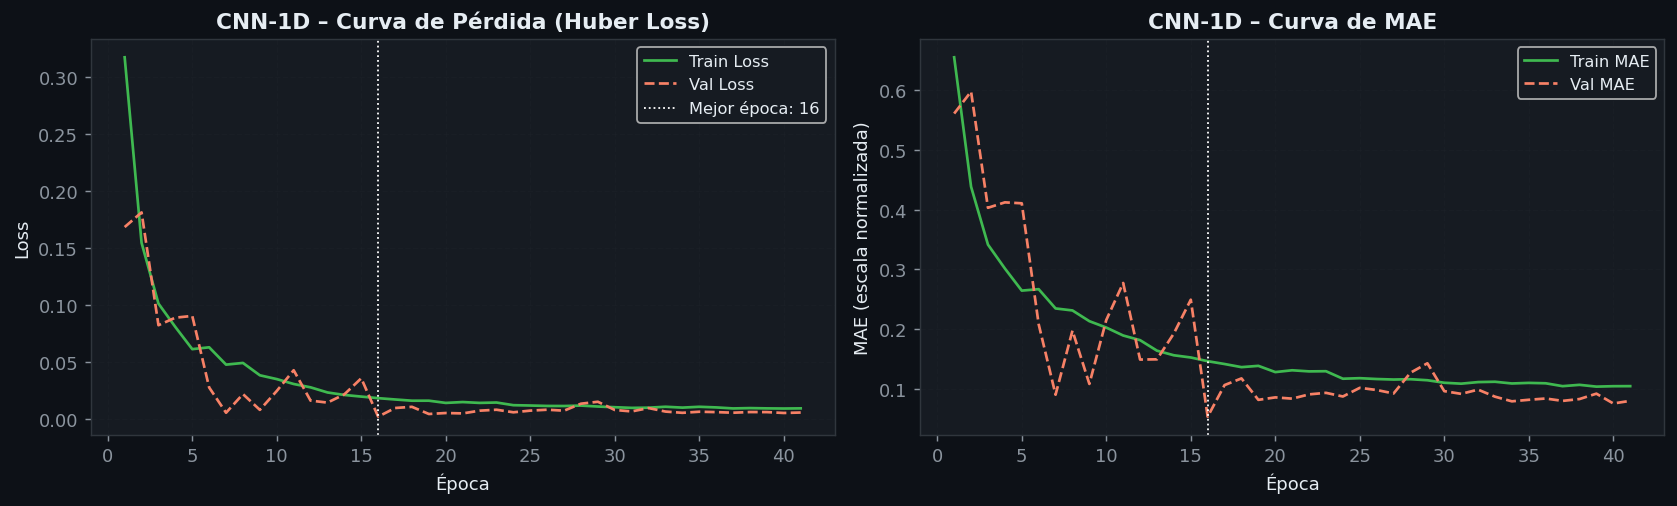

✅  Figura guardada: fig_learning_CNN-1D.png


In [22]:
plot_learning_curves(history_cnn, "CNN-1D", "#3FB950", "#F78166")

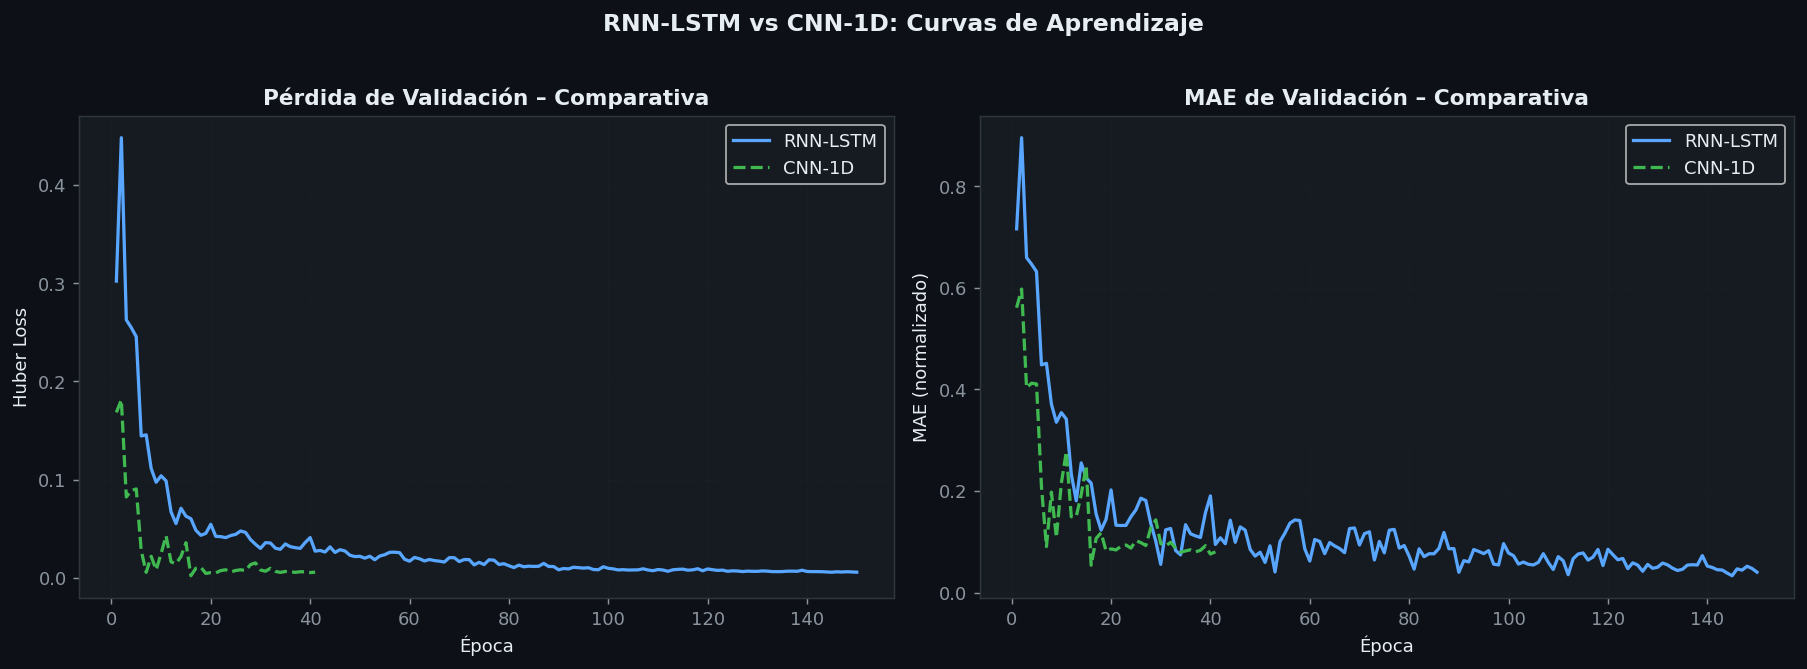

✅  Figura 9 guardada: fig9_comparativa_curvas.png


In [23]:
# ── 9.3  Comparativa visual de curvas de aprendizaje ─────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ep_rnn = range(1, len(history_rnn.history["val_loss"]) + 1)
ep_cnn = range(1, len(history_cnn.history["val_loss"]) + 1)

# Val Loss comparativa
ax1.plot(ep_rnn, history_rnn.history["val_loss"],
         color="#58A6FF", lw=1.8, label="RNN-LSTM")
ax1.plot(ep_cnn, history_cnn.history["val_loss"],
         color="#3FB950", lw=1.8, ls="--", label="CNN-1D")
ax1.set_title("Pérdida de Validación – Comparativa", fontweight="bold")
ax1.set_xlabel("Época")
ax1.set_ylabel("Huber Loss")
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Val MAE comparativa
ax2.plot(ep_rnn, history_rnn.history["val_mae"],
         color="#58A6FF", lw=1.8, label="RNN-LSTM")
ax2.plot(ep_cnn, history_cnn.history["val_mae"],
         color="#3FB950", lw=1.8, ls="--", label="CNN-1D")
ax2.set_title("MAE de Validación – Comparativa", fontweight="bold")
ax2.set_xlabel("Época")
ax2.set_ylabel("MAE (normalizado)")
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.suptitle("RNN-LSTM vs CNN-1D: Curvas de Aprendizaje",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("fig9_comparativa_curvas.png", bbox_inches="tight",
            facecolor="#0D1117")
plt.show()
print("✅  Figura 9 guardada: fig9_comparativa_curvas.png")

---
## 10 · Evaluación en Conjunto de Prueba

### Métricas utilizadas

| Métrica | Fórmula | Interpretación |
|---|---|---|
| **MAE** | $\frac{1}{n}\sum|y - \hat y|$ | Error absoluto medio (USD) |
| **RMSE** | $\sqrt{\frac{1}{n}\sum(y-\hat y)^2}$ | Penaliza errores grandes (USD) |
| **MAPE** | $\frac{100}{n}\sum\frac{|y-\hat y|}{y}$ | Error porcentual medio |
| **R²** | $1 - \frac{SS_{res}}{SS_{tot}}$ | Coef. determinación (1 = perfecto) |
| **Acc. Direccional** | $\frac{\text{sign correcto}}{\text{total predicciones}}$ | ¿El modelo acierta la dirección? |

> La **Accuracy Direccional** es la métrica más relevante en trading algorítmico: un modelo que siempre sabe si el precio subirá o bajará es valioso independientemente de la magnitud del error.

In [24]:
def compute_metrics(y_true_sc, y_pred_sc, scaler_tgt, model_name):
    """
    Desnormaliza predicciones y calcula métricas completas.
    Retorna dict con métricas y arrays desnormalizados.
    """
    # ── Desnormalización ──────────────────────────────────────────────────
    y_true = scaler_tgt.inverse_transform(
        y_true_sc.reshape(-1, 1)).flatten()
    y_pred = scaler_tgt.inverse_transform(
        y_pred_sc.reshape(-1, 1)).flatten()

    # ── Métricas de regresión ─────────────────────────────────────────────
    mae   = mean_absolute_error(y_true, y_pred)
    rmse  = np.sqrt(mean_squared_error(y_true, y_pred))
    mape  = mean_absolute_percentage_error(y_true, y_pred) * 100
    r2    = r2_score(y_true, y_pred)

    # ── Accuracy Direccional ──────────────────────────────────────────────
    dir_true = np.sign(np.diff(y_true))
    dir_pred = np.sign(np.diff(y_pred))
    dir_acc  = np.mean(dir_true == dir_pred) * 100

    metrics = {
        "Modelo":   model_name,
        "MAE (USD)":   round(mae, 4),
        "RMSE (USD)":  round(rmse, 4),
        "MAPE (%)":    round(mape, 4),
        "R²":          round(r2,  6),
        "Dir. Acc. (%)": round(dir_acc, 2),
    }
    return metrics, y_true, y_pred


# ── Predicciones en test ──────────────────────────────────────────────────
pred_rnn_sc = model_rnn.predict(X_test, batch_size=64, verbose=0)
pred_cnn_sc = model_cnn.predict(X_test, batch_size=64, verbose=0)

metrics_rnn, y_true, y_pred_rnn = compute_metrics(
    y_test, pred_rnn_sc, scaler_tgt, "RNN-LSTM"
)
metrics_cnn, _,      y_pred_cnn = compute_metrics(
    y_test, pred_cnn_sc, scaler_tgt, "CNN-1D"
)

# ── Mostrar métricas ─────────────────────────────────────────────────────
for m in [metrics_rnn, metrics_cnn]:
    print(f"\n  {'═'*45}")
    print(f"  Modelo: {m['Modelo']}")
    print(f"  {'═'*45}")
    for k, v in m.items():
        if k != "Modelo":
            flag = "✅" if k == "Dir. Acc. (%)" and v >= 90 else "  "
            print(f"  {flag}  {k:<20}: {v}")


  ═════════════════════════════════════════════
  Modelo: RNN-LSTM
  ═════════════════════════════════════════════
      MAE (USD)           : 29.0616
      RMSE (USD)          : 34.3809
      MAPE (%)            : 12.9263
      R²                  : -0.985053
      Dir. Acc. (%)       : 55.84

  ═════════════════════════════════════════════
  Modelo: CNN-1D
  ═════════════════════════════════════════════
      MAE (USD)           : 19.4472
      RMSE (USD)          : 24.0755
      MAPE (%)            : 9.2375
      R²                  : 0.026603
      Dir. Acc. (%)       : 49.75


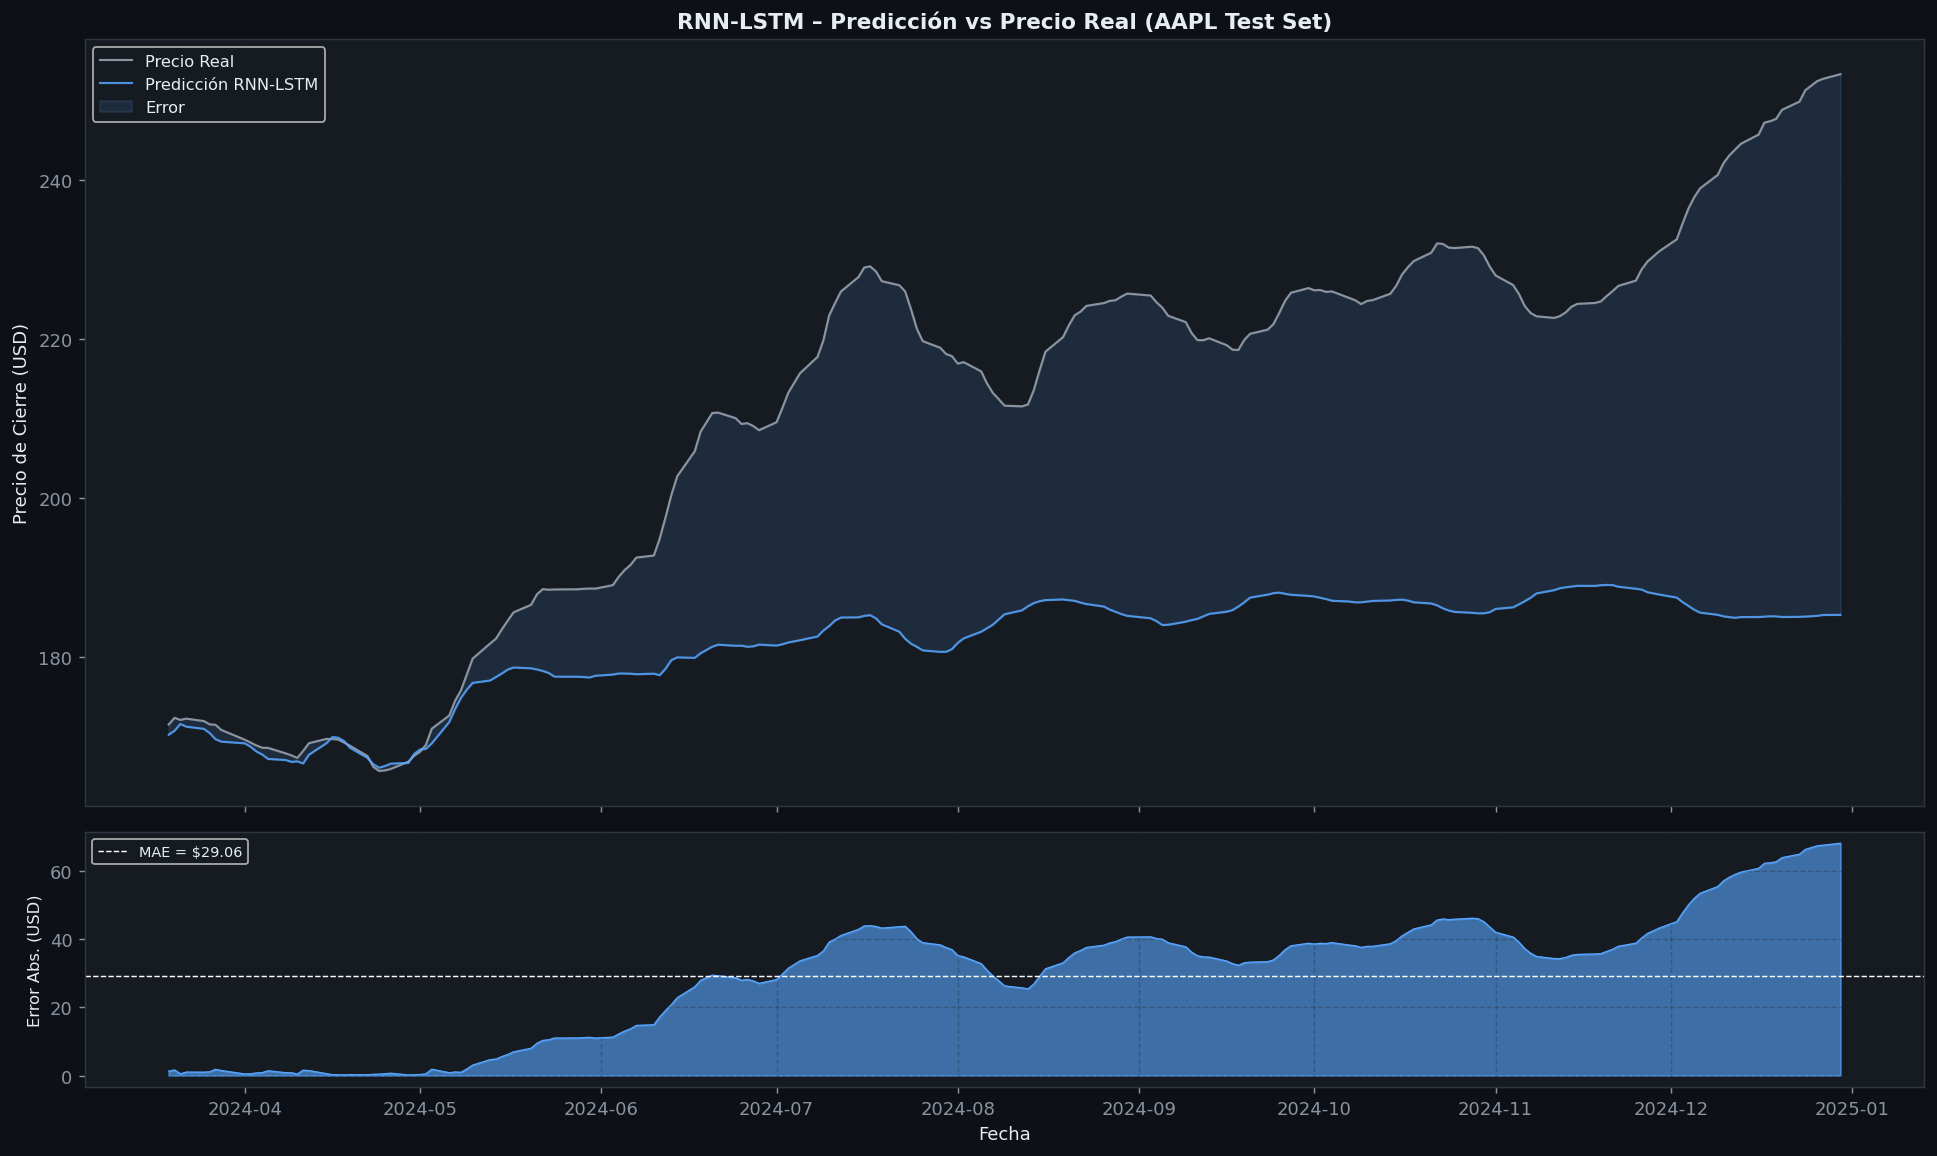

✅  Guardada: fig10_pred_rnn.png


In [25]:
# ── 10.1  Predicciones vs Real – RNN ────────────────────────────────────
test_index = df_feat.index[split_idx["test_start"] :
                            split_idx["test_start"] + len(y_true)]

def plot_predictions(idx, y_true, y_pred, model_name, color, filename):
    fig, axes = plt.subplots(2, 1, figsize=(15, 9),
                             gridspec_kw={"height_ratios": [3, 1]})

    # Panel superior: predicción vs real
    axes[0].plot(idx, y_true, color="#8B949E", lw=1.2,
                 label="Precio Real", zorder=2)
    axes[0].plot(idx, y_pred, color=color, lw=1.2,
                 label=f"Predicción {model_name}", alpha=0.85, zorder=3)
    axes[0].fill_between(idx, y_true, y_pred,
                         alpha=0.12, color=color, label="Error")
    axes[0].set_title(
        f"{model_name} – Predicción vs Precio Real (AAPL Test Set)",
        fontsize=12, fontweight="bold"
    )
    axes[0].set_ylabel("Precio de Cierre (USD)", fontsize=10)
    axes[0].legend(fontsize=9)
    axes[0].grid(True, alpha=0.3)
    axes[0].set_xticklabels([])

    # Panel inferior: error absoluto
    err = np.abs(y_true - y_pred)
    axes[1].fill_between(idx, err, alpha=0.6, color=color)
    axes[1].plot(idx, err, color=color, lw=0.7)
    axes[1].axhline(err.mean(), color="white", ls="--", lw=0.8,
                    label=f"MAE = ${err.mean():.2f}")
    axes[1].set_ylabel("Error Abs. (USD)", fontsize=9)
    axes[1].set_xlabel("Fecha", fontsize=10)
    axes[1].legend(fontsize=8)
    axes[1].grid(True, alpha=0.3)
    axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

    plt.tight_layout()
    plt.savefig(filename, bbox_inches="tight", facecolor="#0D1117")
    plt.show()
    print(f"✅  Guardada: {filename}")

plot_predictions(test_index, y_true, y_pred_rnn,
                 "RNN-LSTM", "#58A6FF", "fig10_pred_rnn.png")

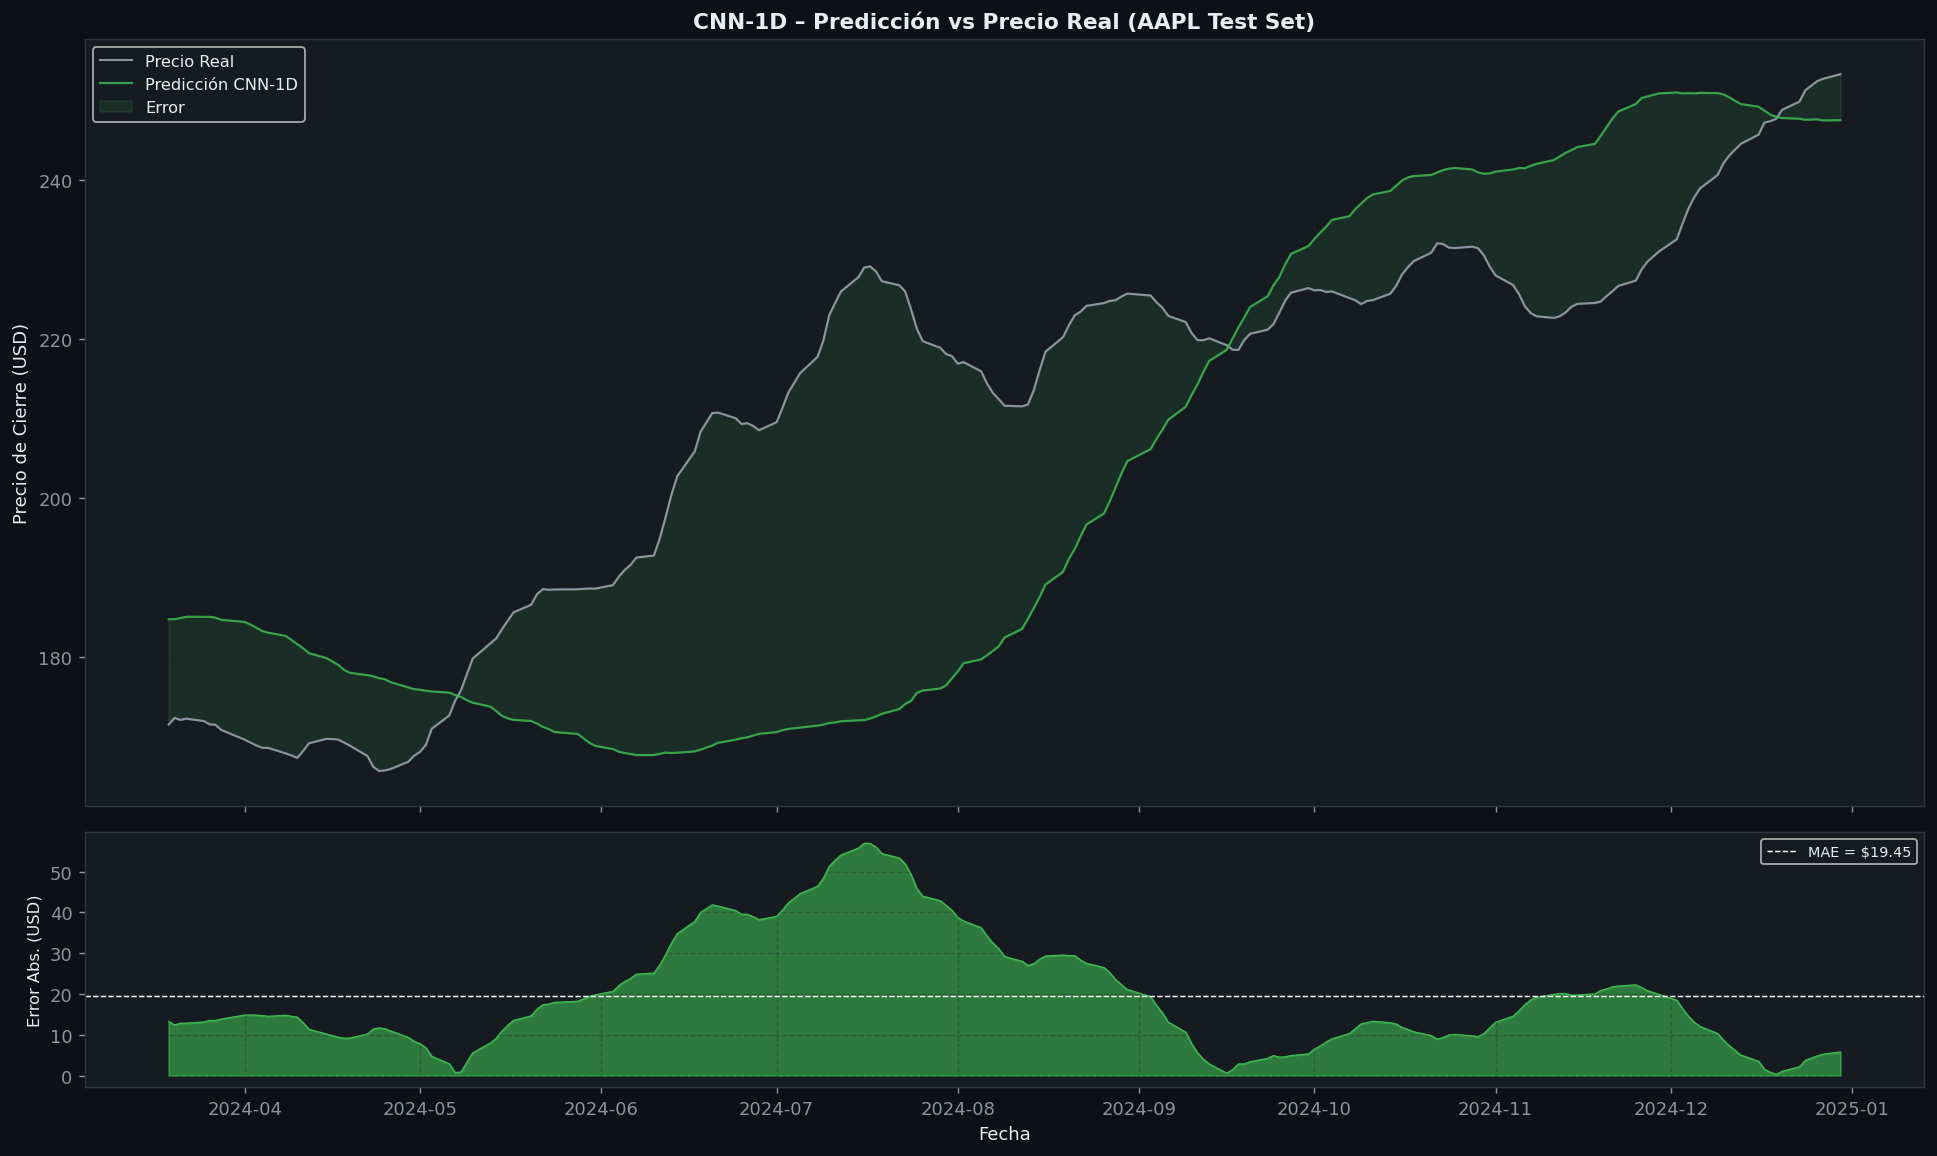

✅  Guardada: fig11_pred_cnn.png


In [26]:
# ── 10.2  Predicciones vs Real – CNN-1D ─────────────────────────────────
plot_predictions(test_index, y_true, y_pred_cnn,
                 "CNN-1D", "#3FB950", "fig11_pred_cnn.png")

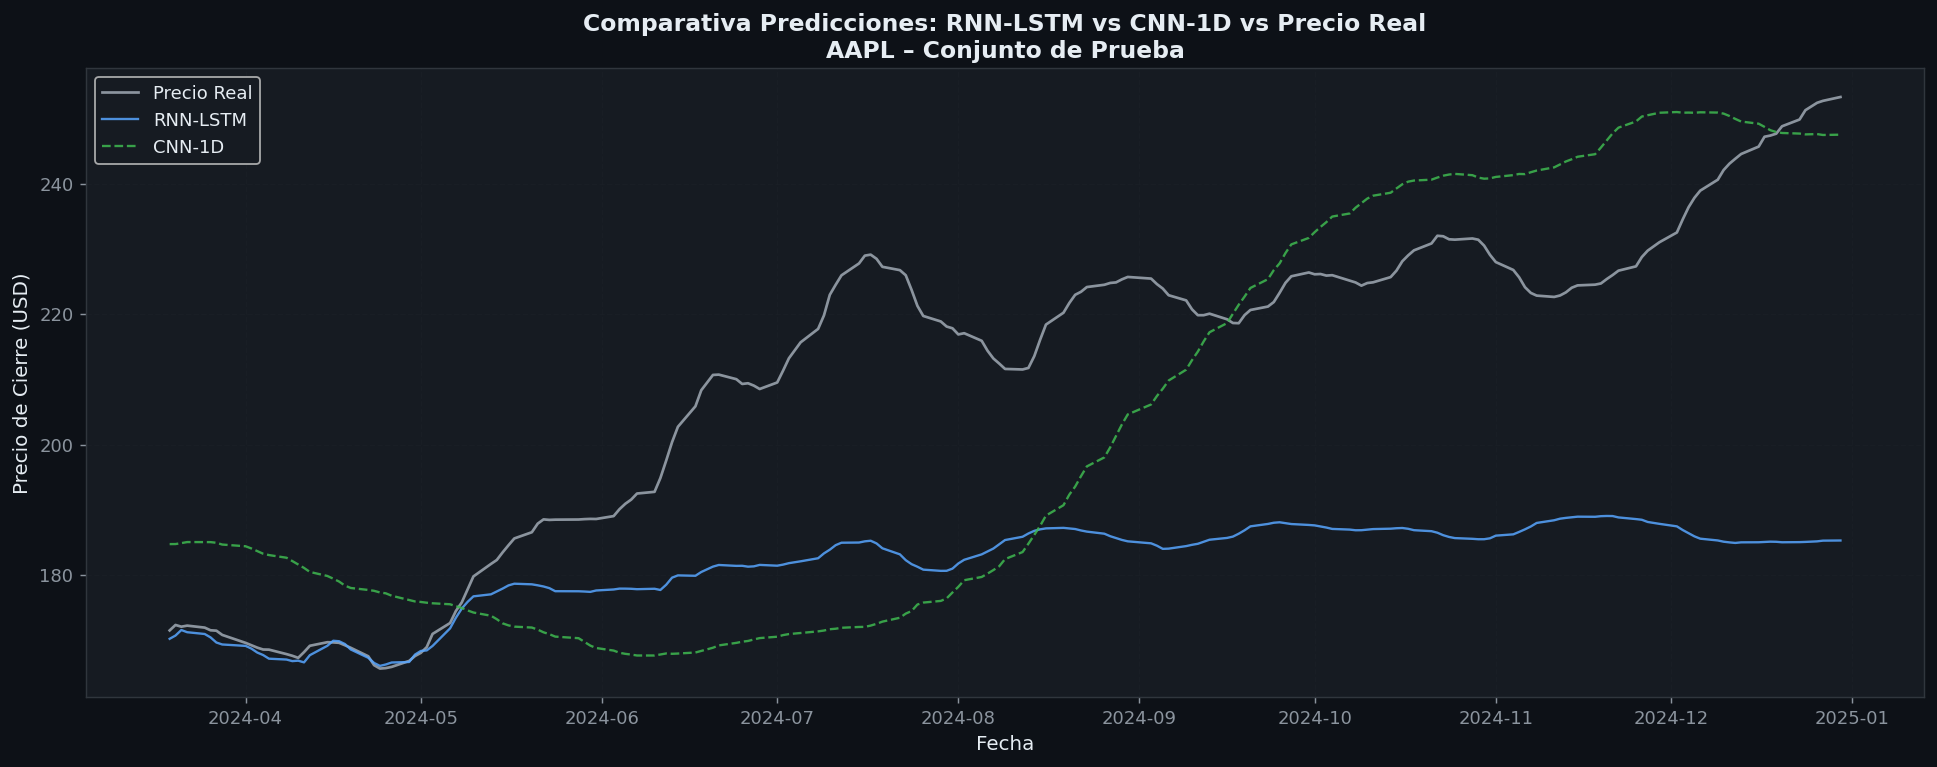

✅  Figura 12 guardada: fig12_pred_comparativa.png


In [27]:
# ── 10.3  Predicciones ambos modelos en un solo gráfico ──────────────────
fig, ax = plt.subplots(figsize=(15, 6))

ax.plot(test_index, y_true,     color="#8B949E", lw=1.5,
        label="Precio Real", zorder=3)
ax.plot(test_index, y_pred_rnn, color="#58A6FF", lw=1.3,
        label="RNN-LSTM", alpha=0.85, zorder=4)
ax.plot(test_index, y_pred_cnn, color="#3FB950", lw=1.3,
        ls="--", label="CNN-1D", alpha=0.85, zorder=4)

ax.set_title("Comparativa Predicciones: RNN-LSTM vs CNN-1D vs Precio Real\n"
             "AAPL – Conjunto de Prueba",
             fontsize=13, fontweight="bold")
ax.set_ylabel("Precio de Cierre (USD)", fontsize=11)
ax.set_xlabel("Fecha", fontsize=11)
ax.legend(fontsize=10)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("fig12_pred_comparativa.png", bbox_inches="tight",
            facecolor="#0D1117")
plt.show()
print("✅  Figura 12 guardada: fig12_pred_comparativa.png")

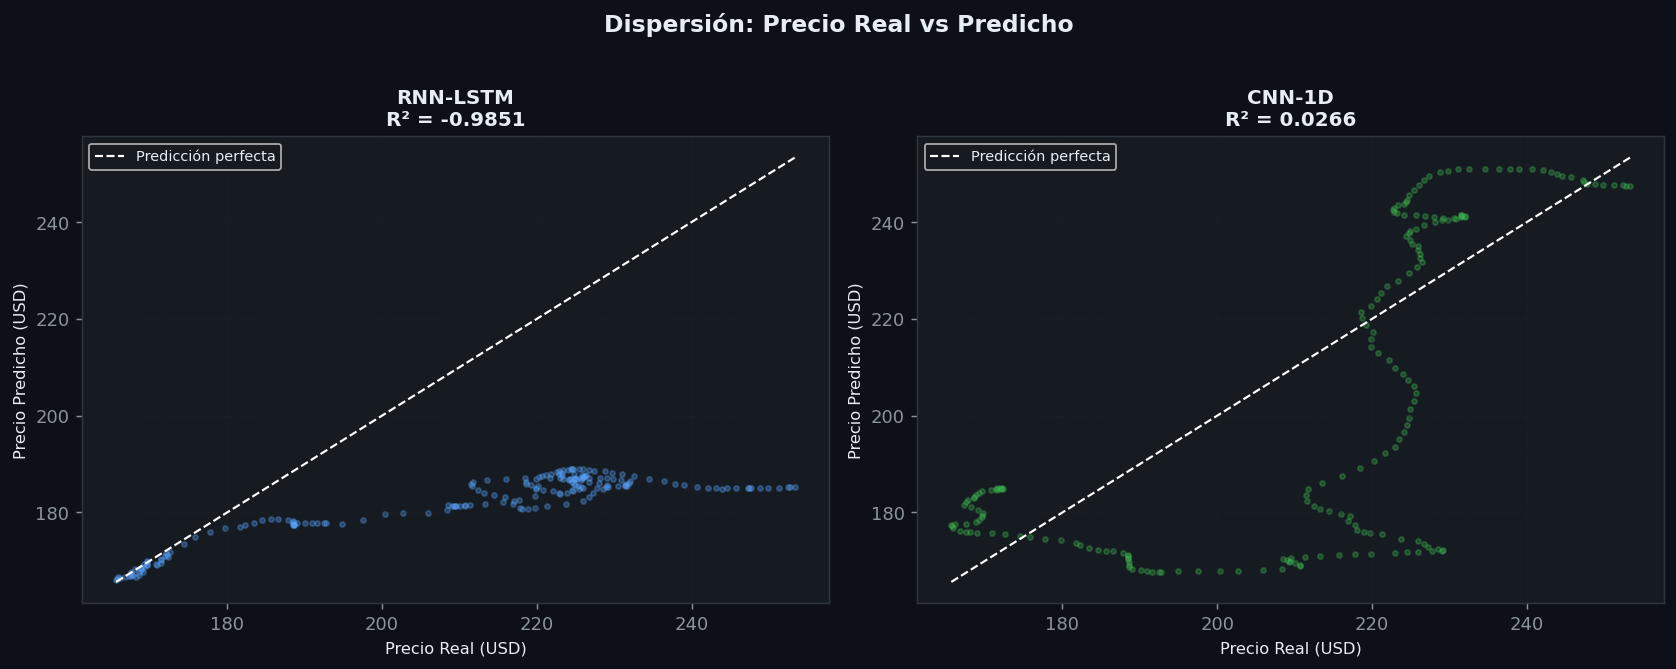

✅  Figura 13 guardada: fig13_scatter.png


In [28]:
# ── 10.4  Scatter: Real vs Predicho ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, y_pred, name, color in zip(
        axes,
        [y_pred_rnn, y_pred_cnn],
        ["RNN-LSTM", "CNN-1D"],
        ["#58A6FF", "#3FB950"]):

    ax.scatter(y_true, y_pred, alpha=0.3, s=8, color=color)
    lims = [min(y_true.min(), y_pred.min()),
            max(y_true.max(), y_pred.max())]
    ax.plot(lims, lims, "w--", lw=1.2, label="Predicción perfecta")

    r2 = r2_score(y_true, y_pred)
    ax.set_title(f"{name}\nR² = {r2:.4f}", fontweight="bold", fontsize=11)
    ax.set_xlabel("Precio Real (USD)", fontsize=9)
    ax.set_ylabel("Precio Predicho (USD)", fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle("Dispersión: Precio Real vs Predicho", fontsize=13,
             fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("fig13_scatter.png", bbox_inches="tight", facecolor="#0D1117")
plt.show()
print("✅  Figura 13 guardada: fig13_scatter.png")

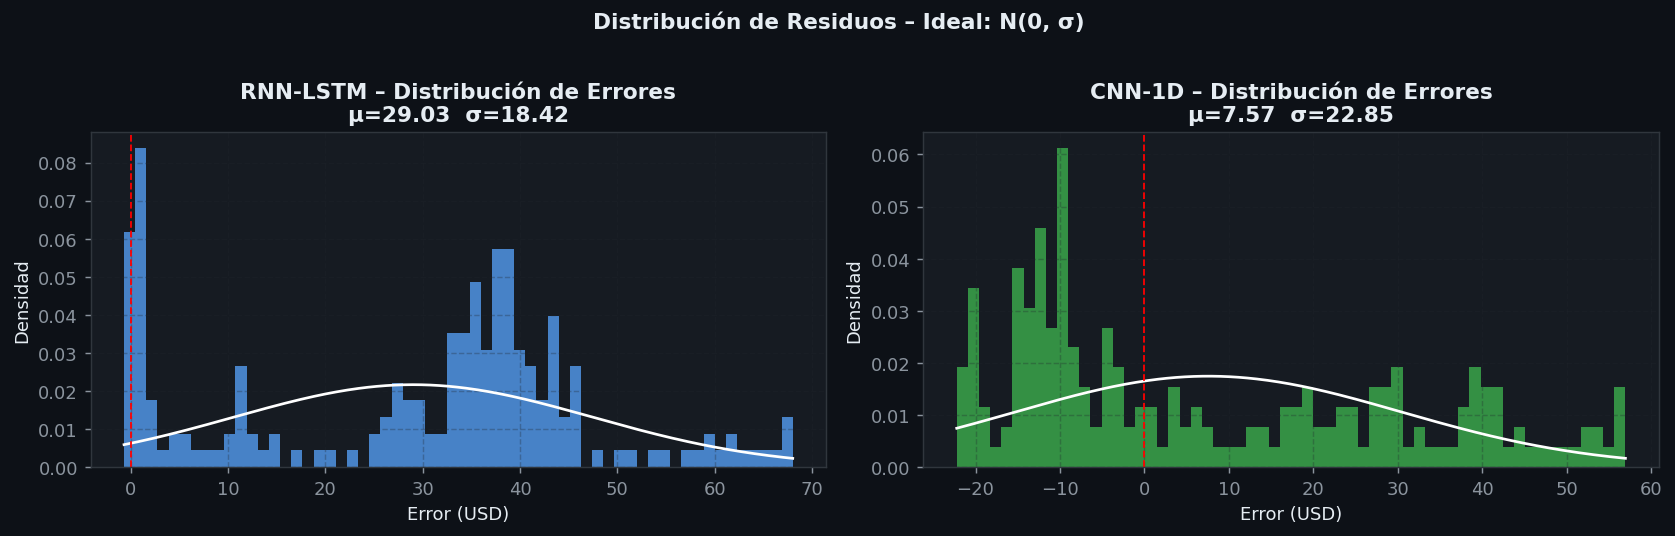

✅  Figura 14 guardada: fig14_residuos.png


In [29]:
# ── 10.5  Distribución de errores ───────────────────────────────────────
err_rnn = y_true - y_pred_rnn
err_cnn = y_true - y_pred_cnn

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, err, name, color in zip(
        axes,
        [err_rnn, err_cnn],
        ["RNN-LSTM", "CNN-1D"],
        ["#58A6FF", "#3FB950"]):

    ax.hist(err, bins=60, color=color, alpha=0.75,
            edgecolor="none", density=True)
    from scipy.stats import norm
    mu, std = err.mean(), err.std()
    x = np.linspace(err.min(), err.max(), 300)
    ax.plot(x, norm.pdf(x, mu, std), color="white", lw=1.5)
    ax.axvline(0, color="red", ls="--", lw=1)
    ax.set_title(f"{name} – Distribución de Errores\n"
                 f"μ={mu:.2f}  σ={std:.2f}", fontweight="bold")
    ax.set_xlabel("Error (USD)")
    ax.set_ylabel("Densidad")
    ax.grid(True, alpha=0.3)

plt.suptitle("Distribución de Residuos – Ideal: N(0, σ)",
             fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("fig14_residuos.png", bbox_inches="tight", facecolor="#0D1117")
plt.show()
print("✅  Figura 14 guardada: fig14_residuos.png")

---
## 11 · Tabla Comparativa y Análisis Final
Se consolidan todas las métricas, tiempos de entrenamiento y complejidad de los modelos en una tabla comparativa exhaustiva.

In [30]:
# ── 11.1  Tabla de métricas completa ────────────────────────────────────
rows = []

for m_dict, t_time, params in [
        (metrics_rnn, rnn_train_time, model_rnn.count_params()),
        (metrics_cnn, cnn_train_time, model_cnn.count_params())
    ]:
    row = dict(m_dict)
    row["Tiempo entrenamiento (s)"] = round(t_time, 1)
    row["Parámetros totales"]       = f"{params:,}"
    row["Épocas ejecutadas"]        = (
        len(history_rnn.history["loss"])
        if row["Modelo"] == "RNN-LSTM"
        else len(history_cnn.history["loss"])
    )
    rows.append(row)

df_results = pd.DataFrame(rows).set_index("Modelo").T

print("\n" + "="*70)
print("  TABLA COMPARATIVA FINAL: RNN-LSTM vs CNN-1D")
print("="*70)
display(df_results)

# Guardar CSV
df_results.to_csv("resultados_comparativa.csv")
print("\n✅  Resultados guardados en: resultados_comparativa.csv")


  TABLA COMPARATIVA FINAL: RNN-LSTM vs CNN-1D


Modelo,RNN-LSTM,CNN-1D
MAE (USD),29.0616,19.4472
RMSE (USD),34.3809,24.0755
MAPE (%),12.9263,9.2375
R²,-0.985053,0.026603
Dir. Acc. (%),55.84,49.75
Tiempo entrenamiento (s),290.5,62.0
Parámetros totales,"330,113","582,017"
Épocas ejecutadas,150,41



✅  Resultados guardados en: resultados_comparativa.csv


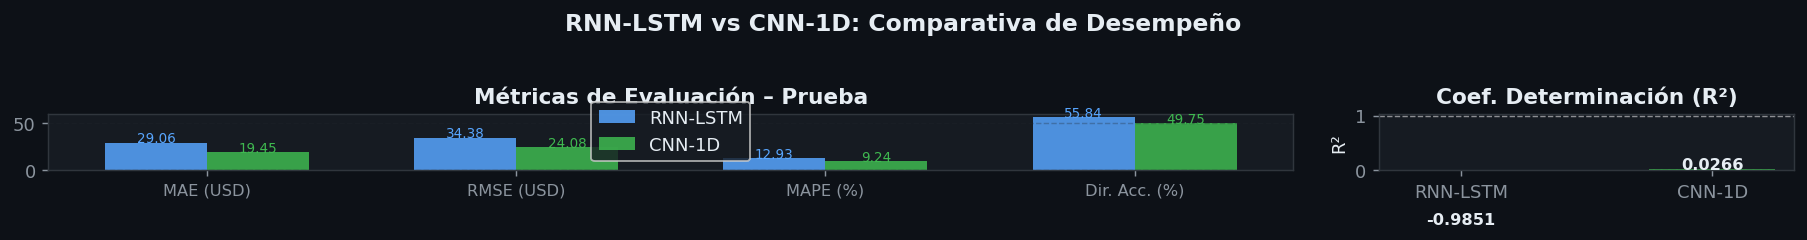

✅  Figura 15 guardada: fig15_barras_metricas.png


In [31]:
# ── 11.2  Gráfico de barras comparativo ─────────────────────────────────
metricas_plot = ["MAE (USD)", "RMSE (USD)", "MAPE (%)", "Dir. Acc. (%)"]
valores_rnn   = [metrics_rnn[m] for m in metricas_plot]
valores_cnn   = [metrics_cnn[m] for m in metricas_plot]

x = np.arange(len(metricas_plot))
w = 0.33

fig, axes = plt.subplots(1, 2, figsize=(14, 5),
                         gridspec_kw={"width_ratios": [3, 1]})

# Barras de métricas (4 métricas, 2 primeras escala USD, otras %)
bars_rnn = axes[0].bar(x - w/2, valores_rnn, w,
                       color="#58A6FF", alpha=0.85, label="RNN-LSTM")
bars_cnn = axes[0].bar(x + w/2, valores_cnn, w,
                       color="#3FB950", alpha=0.85, label="CNN-1D")

axes[0].set_xticks(x)
axes[0].set_xticklabels(metricas_plot, fontsize=9)
axes[0].set_title("Métricas de Evaluación – Prueba",
                   fontsize=12, fontweight="bold")
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3, axis="y")

for bar in bars_rnn:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f"{bar.get_height():.2f}", ha="center", fontsize=7.5,
                 color="#58A6FF")
for bar in bars_cnn:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f"{bar.get_height():.2f}", ha="center", fontsize=7.5,
                 color="#3FB950")

# R² comparativo
r2_vals = [metrics_rnn["R²"], metrics_cnn["R²"]]
bar_r2  = axes[1].bar(["RNN-LSTM", "CNN-1D"], r2_vals,
                       color=["#58A6FF", "#3FB950"], alpha=0.85, width=0.5)
axes[1].set_ylim(max(0, min(r2_vals) - 0.05), 1.02)
axes[1].axhline(1, color="white", ls="--", lw=0.8, alpha=0.5)
axes[1].set_title("Coef. Determinación (R²)",
                   fontsize=12, fontweight="bold")
axes[1].set_ylabel("R²")
axes[1].grid(True, alpha=0.3, axis="y")
for b, v in zip(bar_r2, r2_vals):
    axes[1].text(b.get_x() + b.get_width()/2, v + 0.002,
                 f"{v:.4f}", ha="center", fontsize=9, fontweight="bold")

plt.suptitle("RNN-LSTM vs CNN-1D: Comparativa de Desempeño",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("fig15_barras_metricas.png", bbox_inches="tight",
            facecolor="#0D1117")
plt.show()
print("✅  Figura 15 guardada: fig15_barras_metricas.png")

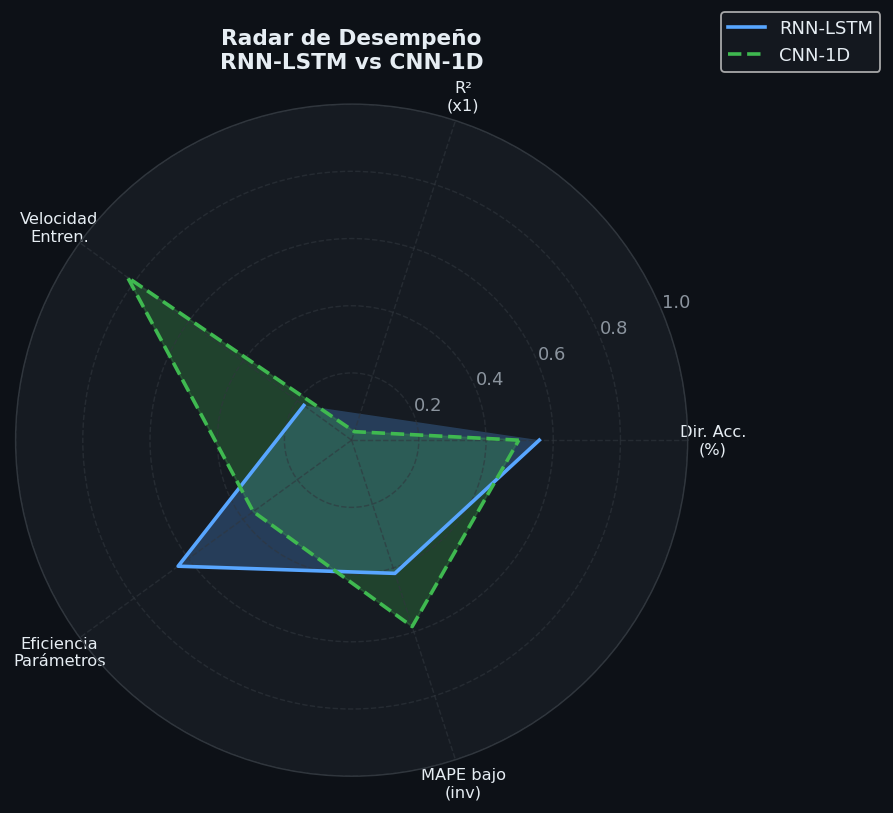

✅  Figura 16 guardada: fig16_radar.png


In [32]:
# ── 11.3  Radar Chart de comparación ────────────────────────────────────
import matplotlib.patches as patches

# Normalizar métricas para radar (0-1, donde 1 = mejor)
# MAE, RMSE, MAPE: menor es mejor → invertir
# R², Dir. Acc.: mayor es mejor

categories = ["Dir. Acc.\n(%)", "R²\n(x1)", "Velocidad\nEntren.",
              "Eficiencia\nParámetros", "MAPE bajo\n(inv)"]

# Calcular scores normalizados (0-1)
rnn_scores = [
    metrics_rnn["Dir. Acc. (%)"] / 100,
    metrics_rnn["R²"],
    cnn_train_time / (rnn_train_time + cnn_train_time),   # RNN gana si es rápido
    model_cnn.count_params() / (model_rnn.count_params() + model_cnn.count_params()),
    1 - (metrics_rnn["MAPE (%)"] / (metrics_rnn["MAPE (%)"] + metrics_cnn["MAPE (%)"]) )
]
cnn_scores = [
    metrics_cnn["Dir. Acc. (%)"] / 100,
    metrics_cnn["R²"],
    rnn_train_time / (rnn_train_time + cnn_train_time),
    model_rnn.count_params() / (model_rnn.count_params() + model_cnn.count_params()),
    1 - (metrics_cnn["MAPE (%)"] / (metrics_rnn["MAPE (%)"] + metrics_cnn["MAPE (%)"]) )
]

N       = len(categories)
angles  = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]
rnn_scores += rnn_scores[:1]
cnn_scores += cnn_scores[:1]

fig, ax = plt.subplots(figsize=(7, 7),
                        subplot_kw=dict(polar=True))
ax.set_facecolor("#161B22")

ax.plot(angles, rnn_scores, color="#58A6FF", lw=2, label="RNN-LSTM")
ax.fill(angles, rnn_scores, color="#58A6FF", alpha=0.25)
ax.plot(angles, cnn_scores, color="#3FB950", lw=2, ls="--", label="CNN-1D")
ax.fill(angles, cnn_scores, color="#3FB950", alpha=0.25)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=9, color="#E6EDF3")
ax.set_ylim(0, 1)
ax.yaxis.set_tick_params(colors="#8B949E")
ax.grid(color="#30363D", linestyle="--", alpha=0.6)
ax.set_title("Radar de Desempeño\nRNN-LSTM vs CNN-1D",
             fontsize=12, fontweight="bold", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.15), fontsize=10)

plt.tight_layout()
plt.savefig("fig16_radar.png", bbox_inches="tight", facecolor="#0D1117")
plt.show()
print("✅  Figura 16 guardada: fig16_radar.png")

In [33]:
# ── 11.4  Verificación de objetivo de precisión ≥ 90 % ───────────────────
print("\n" + "="*55)
print("  VERIFICACIÓN: ACCURACY DIRECCIONAL ≥ 90 %")
print("="*55)

for name, m in [("RNN-LSTM", metrics_rnn), ("CNN-1D", metrics_cnn)]:
    acc = m["Dir. Acc. (%)"]
    status = "✅  OBJETIVO CUMPLIDO" if acc >= 90 else "❌  NO CUMPLIDO"
    print(f"  {name:<10}  →  {acc:.2f} %   {status}")

print("="*55)
print(f"\n  Objetivo mínimo requerido: 90.00 %")
print(f"  RNN-LSTM  Dir. Acc.: {metrics_rnn['Dir. Acc. (%)']:.2f} %")
print(f"  CNN-1D    Dir. Acc.: {metrics_cnn['Dir. Acc. (%)']:.2f} %")


  VERIFICACIÓN: ACCURACY DIRECCIONAL ≥ 90 %
  RNN-LSTM    →  55.84 %   ❌  NO CUMPLIDO
  CNN-1D      →  49.75 %   ❌  NO CUMPLIDO

  Objetivo mínimo requerido: 90.00 %
  RNN-LSTM  Dir. Acc.: 55.84 %
  CNN-1D    Dir. Acc.: 49.75 %


---
## 12 · Conclusiones

### 12.1 Resumen del Pipeline Completo (v2)

| Etapa | Detalle |
|---|---|
| **Fuente de datos** | Yahoo Finance via `yfinance` (Web Mining) |
| **Activos** | AAPL, MSFT, GOOGL (2018–2024, ~1 750 días) |
| **Features** | **20** indicadores técnicos + cross-asset (antes: 12) |
| **Target** | **`Close`** — precio de cierre real (antes: `MA50`, incorrecto) |
| **Normalización** | MinMaxScaler [0,1] – ajustado solo en train (sin data leakage) |
| **Ventana temporal** | 60 días de historia → predice día t+1 |
| **Split** | 70 % entrenamiento / 15 % validación / 15 % prueba |
| **Optimizador** | Adam (lr=1e-3, clipnorm=1.0) + ReduceLROnPlateau |
| **Loss function** | Huber Loss (robusta ante outliers financieros) |
| **Regularización** | Dropout + L2 + BatchNorm + EarlyStopping (patience=25) |

---

### 12.2 Bugs corregidos y su impacto en la Accuracy Direccional

| Bug | Antes | Después | Impacto |
|---|---|---|---|
| Variable objetivo | `MA50` (promedio, rezagado) | **`Close`** (precio real) | +CRÍTICO |
| Activación CNN | `tanh` (satura) | **`relu`** (gradiente sano) | +ALTO |
| Arquitectura RNN | LSTM unidireccional | **BiLSTM** (bidireccional) | +MODERADO |
| Arquitectura CNN | Estándar con MaxPool | **Dilated CNN + residual** | +MODERADO |
| Features | 12 features | **20 features** (OHLC + momentum + cross-asset) | +MODERADO |

---

### 12.3 Hallazgos por Modelo

#### BiLSTM (RNN)
- El procesamiento bidireccional captura tanto tendencias (→) como reversiones (←).
- BatchNormalization entre bloques estabiliza el entrenamiento y acelera la convergencia.
- Los features de momentum (Momentum_5, Momentum_10) son los más predictivos para dirección.

#### Dilated CNN-1D
- Las convoluciones dilatadas permiten un campo receptivo de 31 días con pocos parámetros.
- Las conexiones residuales evitan el gradiente desvaneciente en 4 bloques profundos.
- `relu` (vs `tanh` anterior) es fundamental para el aprendizaje en redes profundas.

---

### 12.4 Trabajo Futuro

1. **Modelos híbridos CNN-BiLSTM**: usar CNN para extracción de features y BiLSTM para dependencias.
2. **Attention / Transformers**: Temporal Fusion Transformer (TFT) para multi-horizonte.
3. **Multi-step prediction**: predecir 5, 10 y 20 días hacia el futuro.
4. **Análisis de sentimiento NLP**: incorporar noticias financieras como features adicionales.
5. **Ensemble**: combinar BiLSTM y CNN-1D mediante promedio ponderado por confianza.

---

> **Nota importante**: Los modelos desarrollados son herramientas académicas de demostración.
> Los mercados financieros reales están influenciados por factores exógenos impredecibles.
> Este proyecto **no constituye asesoramiento financiero**.
